# DGFF — End-to-End Low-Light Enhancement with Detection-Guided Feature Feedback



**Single-notebook implementation** of the full pipeline:
- `LOLDataset` — paired low/high dataloader
- `LLEN` — U-Net encoder-decoder with DGFF injection points
- `DGFFModule` — YOLOv8 backbone + gated adapters (v2 with sigmoid gate)
- `PerceptualLoss` + `DetectionFeatureLoss` — composite training objective
- Training loop with λ_det curriculum
- Validation (PSNR / SSIM)
- Results visualisation

**Dataset**: LOL (485 train / 15 val)  
**Detector**: YOLOv8n (backbone frozen, adapters trained)  
**Loss**: L1 + λ_perc·L_perc + λ_det·L_det (ramped)

---
## 0 — Imports & Config

In [24]:
import os
import random
import time
from pathlib import Path

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import Adam
from torch.optim.lr_scheduler import CosineAnnealingLR
from torch.utils.data import Dataset, DataLoader

import torchvision.transforms as T
import torchvision.transforms.functional as TF
import torchvision.models as models

from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np

from ultralytics import YOLO

# ── Device ────────────────────────────────────────────────────────────────────
DEVICE = (
    torch.device('mps')  if torch.backends.mps.is_available() else
    torch.device('cuda') if torch.cuda.is_available()         else
    torch.device('cpu')
)
print(f"Device : {DEVICE}")

# Config 
CFG = dict(
    # Data
    lol_root      = './LOL',          # path to LOL dataset root
    crop_size     = 256,              # training crop size

    # Model
    base_ch       = 32,               # LLEN base channels (32 → 32/64/128/256)
    yolo_weights  = 'yolov8n.pt',     # YOLOv8n weights (auto-download)

    # Training
    epochs        = 200,              # total epochs (was 3 for test)
    batch_size    = 4,                # images per batch (reduce to 2 if OOM)
    lr            = 1e-4,             # learning rate
    lambda_perc   = 0.1,              # perceptual loss weight
    lambda_det    = 0.5,              # max detection loss weight (ramped from 0)
    val_every     = 5,                # validate every N epochs
    num_workers   = 0,                # set 0 for Jupyter on Mac/Windows

    # Paths
    ckpt_dir      = './checkpoints',  # where to save best.pt and epoch_*.pt
)

Path(CFG['ckpt_dir']).mkdir(parents=True, exist_ok=True)
print("Config OK")

Device : mps
Config OK


---
## 1 — Dataset

In [25]:
class LOLDataset(Dataset):
    """
    Paired (low-light, normal-light) loader for the LOL dataset.

    LOL structure:
        LOL/
        ├── our485/low/   our485/high/   (485 train pairs)
        └── eval15/low/   eval15/high/   (15 val pairs)

    Download: https://drive.google.com/file/d/157bjO1_cFoSJ2FapgwwPM4I2beZlYXoO
    """
    SPLIT_DIRS = {'train': 'our485', 'val': 'eval15'}
    _IMG_EXTS  = {'.png', '.jpg', '.jpeg', '.bmp', '.tif', '.tiff'}

    def __init__(self, root, split='train', crop_size=256, augment=True):
        assert split in self.SPLIT_DIRS
        self.crop_size = crop_size
        self.augment   = augment and (split == 'train')

        base          = Path(root) / self.SPLIT_DIRS[split]
        self.low_dir  = base / 'low'
        self.high_dir = base / 'high'

        for d in (self.low_dir, self.high_dir):
            if not d.is_dir():
                raise FileNotFoundError(f"Not found: {d}")

        self.filenames = sorted(
            f for f in os.listdir(self.low_dir)
            if Path(f).suffix.lower() in self._IMG_EXTS
        )
        missing = [f for f in self.filenames if not (self.high_dir / f).exists()]
        if missing:
            raise FileNotFoundError(f"Missing high images: {missing[:3]}")

        self.to_tensor = T.ToTensor()

    def __len__(self):
        return len(self.filenames)

    def __getitem__(self, idx):
        fname    = self.filenames[idx]
        low_img  = Image.open(self.low_dir  / fname).convert('RGB')
        high_img = Image.open(self.high_dir / fname).convert('RGB')

        if self.crop_size is not None:
            low_img, high_img = self._paired_crop(low_img, high_img)

        if self.augment and random.random() > 0.5:
            low_img  = TF.hflip(low_img)
            high_img = TF.hflip(high_img)

        return self.to_tensor(low_img), self.to_tensor(high_img), fname

    def _paired_crop(self, low, high):
        w, h = low.size
        c    = self.crop_size
        if w < c or h < c:
            return TF.resize(low, [c, c]), TF.resize(high, [c, c])
        top  = random.randint(0, h - c)
        left = random.randint(0, w - c)
        return TF.crop(low, top, left, c, c), TF.crop(high, top, left, c, c)


def get_loaders(cfg):
    train_set = LOLDataset(cfg['lol_root'], 'train', cfg['crop_size'], augment=True)
    val_set   = LOLDataset(cfg['lol_root'], 'val',   None,            augment=False)

    train_loader = DataLoader(train_set, batch_size=cfg['batch_size'],
                              shuffle=True,  num_workers=cfg['num_workers'],
                              drop_last=True,  pin_memory=False)
    val_loader   = DataLoader(val_set,   batch_size=1,
                              shuffle=False, num_workers=cfg['num_workers'],
                              drop_last=False, pin_memory=False)
    return train_loader, val_loader


# Quick check
train_loader, val_loader = get_loaders(CFG)
low, high, fnames = next(iter(train_loader))
print(f"Train: {len(train_loader.dataset)} pairs | Val: {len(val_loader.dataset)} pairs")
print(f"Batch low={tuple(low.shape)}  high={tuple(high.shape)}  range=[{low.min():.2f},{low.max():.2f}]")

Train: 485 pairs | Val: 15 pairs
Batch low=(4, 3, 256, 256)  high=(4, 3, 256, 256)  range=[0.00,0.24]


---
## 2 — LLEN (Low-Light Enhancement Network)

In [26]:
# ── Building blocks ───────────────────────────────────────────────────────────
import torch.nn.functional as F
class ResBlock(nn.Module):
    """Two-layer residual block. Keeps spatial size."""
    def __init__(self, ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(ch, ch, 3, padding=1, bias=False), nn.BatchNorm2d(ch), nn.ReLU(True),
            nn.Conv2d(ch, ch, 3, padding=1, bias=False), nn.BatchNorm2d(ch),
        )
        self.relu = nn.ReLU(True)

    def forward(self, x):
        return self.relu(x + self.block(x))


class EncoderBlock(nn.Module):
    """Conv → ResBlock → (skip, downsampled)."""
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch), nn.ReLU(True),
        )
        self.res  = ResBlock(out_ch)
        self.down = nn.MaxPool2d(2)

    def forward(self, x):
        x    = self.res(self.conv(x))
        skip = x
        return self.down(x), skip


class DecoderBlock(nn.Module):
    def __init__(self, in_ch, skip_ch, out_ch, feedback_ch=32):
        super().__init__()
        self.merge = nn.Sequential(
            nn.Conv2d(in_ch + skip_ch, out_ch, 1, bias=False),
            nn.BatchNorm2d(out_ch), nn.ReLU(True),
        )
        self.res = ResBlock(out_ch)
        if feedback_ch is not None:
            self.feedback_proj = nn.Conv2d(feedback_ch, out_ch, 1, bias=False)
        else:
            self.feedback_proj = None

    def forward(self, x, skip, feedback=None):
        x = F.interpolate(x, size=skip.shape[-2:], mode='bilinear', align_corners=False)
        x = self.merge(torch.cat([x, skip], dim=1))
        if feedback is not None and self.feedback_proj is not None:
            if feedback.shape[-2:] != x.shape[-2:]:
                feedback = F.interpolate(feedback, size=x.shape[-2:],
                                         mode='bilinear', align_corners=False)
            x = x + self.feedback_proj(feedback)   # ← actually use the proj
        return self.res(x)


# ── Full network ──────────────────────────────────────────────────────────────

class LLEN(nn.Module):

    def __init__(self, base_ch=32):
        super().__init__()
        c = base_ch

        self.enc1 = EncoderBlock(3,   c)      # skip: (B,  c,  H,   W)
        self.enc2 = EncoderBlock(c,   c*2)    # skip: (B, 2c, H/2, W/2)
        self.enc3 = EncoderBlock(c*2, c*4)    # skip: (B, 4c, H/4, W/4)
        self.enc4 = EncoderBlock(c*4, c*8)    # skip: (B, 8c, H/8, W/8)

        self.bottleneck = nn.Sequential(ResBlock(c*8), ResBlock(c*8))

        self.dec4 = DecoderBlock(c*8, c*8, c*4, feedback_ch=c*4)  # P5 → 128ch
        self.dec3 = DecoderBlock(c*4, c*4, c*2, feedback_ch=c*2)  # P4 → 64ch
        self.dec2 = DecoderBlock(c*2, c*2, c,   feedback_ch=c)    # P3 → 32ch
        self.dec1 = DecoderBlock(c,   c,   c,   feedback_ch=None)  # no injection

        self.head = nn.Sequential(
            nn.Conv2d(c, c, 3, padding=1, bias=False), nn.ReLU(True),
            nn.Conv2d(c, 3, 1), nn.Sigmoid(),
        )

    def forward(self, x, dgff_p5=None, dgff_p4=None, dgff_p3=None):
        x, s1 = self.enc1(x)
        x, s2 = self.enc2(x)
        x, s3 = self.enc3(x)
        x, s4 = self.enc4(x)
        x     = self.bottleneck(x)
        x     = self.dec4(x, s4, feedback=dgff_p5)
        x     = self.dec3(x, s3, feedback=dgff_p4)
        x     = self.dec2(x, s2, feedback=dgff_p3)   
        x     = self.dec1(x, s1)                      
        return self.head(x)

    def count_parameters(self):
        return sum(p.numel() for p in self.parameters() if p.requires_grad)


# Smoke test
llen_test = LLEN(CFG['base_ch'])
dummy     = torch.rand(1, 3, 256, 256)
out       = llen_test(dummy)
assert out.shape == dummy.shape and out.min() >= 0 and out.max() <= 1
print(f"LLEN params: {llen_test.count_parameters():,}")
print(f"LLEN forward: {tuple(dummy.shape)} → {tuple(out.shape)}  ✓")
del llen_test, dummy, out

LLEN params: 4,844,803
LLEN forward: (1, 3, 256, 256) → (1, 3, 256, 256)  ✓


---
## 3 — DGFF Module (v2 — Gated Adapters)

In [27]:
"""
dgff_v2.py — DGFF Module with Channel Gating
=============================================
... (docstring unchanged)
"""

import torch
import torch.nn as nn
from ultralytics import YOLO


class GatedAdapter(nn.Module):
    """ ... (unchanged) ... """
    def __init__(self, in_ch: int, out_ch: int):
        super().__init__()
        self.proj = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, kernel_size=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )
        self.gate = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, kernel_size=1, bias=False),
            nn.Sigmoid(),
        )

    def forward(self, f_det, target_size):
        f_det = nn.functional.interpolate(
            f_det, size=target_size, mode='bilinear', align_corners=False
        )
        return self.gate(f_det) * self.proj(f_det)


class DGFFModule(nn.Module):


    def __init__(
        self,
        yolo_weights: str = 'yolov8n.pt',
        llen_base_ch: int = 32,
        freeze_backbone: bool = True,
    ):
        super().__init__()

        # Load YOLOv8 backbone (first 10 layers = up to P5)
        yolo = YOLO(yolo_weights)
        self.backbone = yolo.model.model[:10]

        if freeze_backbone:
            for p in self.backbone.parameters():
                p.requires_grad_(False)

        # Probe actual channel depths
        with torch.no_grad():
            probe = torch.zeros(1, 3, 64, 64)
            out = probe
            for i, layer in enumerate(self.backbone):
                out = layer(out)
                if i == 4:
                    actual_p3 = out.shape[1]
                if i == 6:
                    actual_p4 = out.shape[1]
                if i == 9:
                    actual_p5 = out.shape[1]
        self.p3_ch = actual_p3
        self.p4_ch = actual_p4
        self.p5_ch = actual_p5

        # Build gated adapters
        c = llen_base_ch
        self._llen_base_ch = c
        self.adapter_p3 = GatedAdapter(self.p3_ch, c)
        self.adapter_p5 = GatedAdapter(self.p5_ch, c * 4)   # P5 -> dec4 (128ch)
        self.adapter_p4 = GatedAdapter(self.p4_ch, c * 2)   # P4 -> dec3 (64ch)

    def forward(self, enhanced_img):
    
        x = enhanced_img
        p4_raw = None
        p5_raw = None

        for i, layer in enumerate(self.backbone):
            x = layer(x)
            if i == 4:
                p3_raw = x
            if i == 6:
                p4_raw = x
            if i == 9:
                p5_raw = x

        if p3_raw is None or p4_raw is None or p5_raw is None:
            raise RuntimeError("Could not extract P4/P5 from backbone. Check layer indices.")

        c = self._llen_base_ch
        H_input, W_input = enhanced_img.shape[-2:]

        p5_size = (H_input // 8, W_input // 8)   # dec4 spatial size
        p4_size = (H_input // 4, W_input // 4)   # dec3 spatial size
        p3_size = (H_input // 2, W_input // 2)

        p5_feedback = self.adapter_p5(p5_raw, p5_size)
        p4_feedback = self.adapter_p4(p4_raw, p4_size)
        p3_feedback = self.adapter_p3(p3_raw, p3_size)

        return p4_feedback, p5_feedback, p3_feedback

    def count_parameters(self):
        total = sum(p.numel() for p in self.parameters())
        trainable = sum(p.numel() for p in self.parameters() if p.requires_grad)
        return total, trainable



# Smoke test


if __name__ == '__main__':
    import sys

    print("DGFFv2 Smoke Test")
    device = torch.device('cpu')

    try:
        dgff = DGFFModule(yolo_weights='yolov8n.pt', llen_base_ch=32).to(device)
    except Exception as e:
        print(f"[SKIP] Could not load YOLOv8: {e}")
        sys.exit(0)

    total, trainable = dgff.count_parameters()
    print(f"  Params total / trainable: {total:,} / {trainable:,}")

    dummy = torch.rand(2, 3, 256, 256)
    p4, p5, p3 = dgff(dummy)
    print(f"  P4 feedback shape: {tuple(p4.shape)}  (expected: 2,  64,  64,  64)")
    print(f"  P5 feedback shape: {tuple(p5.shape)}  (expected: 2, 128,  32,  32)")
    print(f"  P3 feedback shape: {tuple(p3.shape)}  (expected: 2,  64, 128, 128)")
    print("  Smoke test passed ✓")

DGFFv2 Smoke Test
  Params total / trainable: 1,359,120 / 86,464
  P4 feedback shape: (2, 64, 64, 64)  (expected: 2,  64,  64,  64)
  P5 feedback shape: (2, 128, 32, 32)  (expected: 2, 128,  32,  32)
  P3 feedback shape: (2, 32, 128, 128)  (expected: 2,  64, 128, 128)
  Smoke test passed ✓


---
## 4 — Loss Functions

In [28]:
# ── Perceptual Loss (VGG-16 relu2_2 + relu3_3) ───────────────────────────────

class PerceptualLoss(nn.Module):
    """Feature matching loss on VGG-16 intermediate activations."""
    def __init__(self, device):
        super().__init__()
        vgg          = models.vgg16(weights=models.VGG16_Weights.DEFAULT).features
        self.slice1  = nn.Sequential(*list(vgg)[:10]).to(device).eval()
        self.slice2  = nn.Sequential(*list(vgg)[:17]).to(device).eval()
        for p in self.parameters(): p.requires_grad_(False)

        mean = torch.tensor([0.485, 0.456, 0.406], device=device).view(1,3,1,1)
        std  = torch.tensor([0.229, 0.224, 0.225], device=device).view(1,3,1,1)
        self.register_buffer('mean', mean)
        self.register_buffer('std',  std)

    def forward(self, pred, target):
        pred   = (pred   - self.mean) / self.std
        target = (target - self.mean) / self.std
        return F.mse_loss(self.slice1(pred), self.slice1(target)) + \
               F.mse_loss(self.slice2(pred), self.slice2(target))


# ── Detection Feature Loss ────────────────────────────────────────────────────

class DetectionFeatureLoss(nn.Module):
    """
    Core detection-guidance loss.  Minimises the L2 distance between
    YOLOv8 backbone features extracted from (a) the DGFF-guided enhanced
    image and (b) the clean normal-light reference.

    Interpretation: if the enhancer produces the same internal detector
    activations as the clean image, the detector will fire identically
    on both — which is exactly the task-oriented objective.

    Why this instead of pseudo-label box loss:
      - LOL has no detection annotations
      - Feature-level loss gives dense gradients (not sparse bbox regression)
      - No threshold or NMS tuning required
      - Gradient flows cleanly: backbone → DGFF adapters → LLEN decoder

    Shares the backbone from DGFFModule — no extra memory.
    """
    def __init__(self, dgff_module):
        super().__init__()
        self.backbone = dgff_module.backbone   # shared, already frozen or not

    def _extract(self, x, no_grad=False):
        feats = []
        ctx   = torch.no_grad() if no_grad else torch.enable_grad()
        with ctx:
            for i, layer in enumerate(self.backbone):
                x = layer(x)
                if i in (4, 6, 9):    # P3, P4 and P5
                    feats.append(x)
        return feats

    def forward(self, enhanced_guided, high):
        feats_enh   = self._extract(enhanced_guided, no_grad=False)
        feats_clean = self._extract(high,            no_grad=True)
        loss = sum(F.mse_loss(fe, fc.detach())
                   for fe, fc in zip(feats_enh, feats_clean))
        return loss


# ── Metrics ───────────────────────────────────────────────────────────────────

def compute_psnr(pred, target):
    mse = F.mse_loss(pred, target).item()
    return float('inf') if mse == 0 else 10 * torch.log10(torch.tensor(1.0 / mse)).item()

def compute_ssim(pred, target):
    try:
        from pytorch_msssim import ssim
        return ssim(pred, target, data_range=1.0).item()
    except ImportError:
        mu1, mu2 = pred.mean(), target.mean()
        s1, s2   = pred.std(),  target.std()
        s12      = ((pred - mu1) * (target - mu2)).mean()
        C1, C2   = 0.01**2, 0.03**2
        return (((2*mu1*mu2+C1)*(2*s12+C2)) / ((mu1**2+mu2**2+C1)*(s1**2+s2**2+C2))).item()

print("Loss functions defined ✓")

Loss functions defined ✓


---
## 5 — Model Instantiation

In [29]:
llen = LLEN(base_ch=CFG['base_ch']).to(DEVICE)
dgff = DGFFModule(
    yolo_weights    = CFG['yolo_weights'],
    llen_base_ch    = CFG['base_ch'],
    freeze_backbone = True,
).to(DEVICE)

perc_loss = PerceptualLoss(DEVICE)
det_loss  = DetectionFeatureLoss(dgff).to(DEVICE)
l1_loss   = nn.L1Loss()

# Optimise LLEN + adapter layers; backbone stays frozen
trainable = (
    list(llen.parameters()) +
    list(dgff.adapter_p3.parameters()) +
    list(dgff.adapter_p4.parameters()) +
    list(dgff.adapter_p5.parameters())
)
optimiser = Adam(trainable, lr=CFG['lr'], betas=(0.9, 0.999))
scheduler = CosineAnnealingLR(optimiser, T_max=CFG['epochs'], eta_min=1e-6)

tot, tr = dgff.count_parameters()
print(f"LLEN params         : {llen.count_parameters():,}")
print(f"DGFF total/trainable: {tot:,} / {tr:,}")
print(f"Optimiser params    : {sum(p.numel() for p in trainable):,}")

LLEN params         : 4,844,803
DGFF total/trainable: 1,359,120 / 86,464
Optimiser params    : 4,931,267


---
## 6 — Training Loop

In [30]:
from tqdm import tqdm
import time

# Device setup for Apple Silicon
DEVICE = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')
print(f"Using device: {DEVICE}")

# Mixed precision is not available on MPS, disable
use_amp = False
scaler = None

# Trainable parameters (LLEN + DGFF adapters)
trainable = list(llen.parameters()) + list(dgff.adapter_p4.parameters()) + list(dgff.adapter_p5.parameters()) + list(dgff.adapter_p3.parameters())

# Loss functions (ensure these are defined earlier)
l1_loss = nn.L1Loss()
perc_loss = PerceptualLoss(DEVICE)
det_loss = DetectionFeatureLoss(dgff).to(DEVICE)

# Curriculum function
def get_lambda_det(epoch, total_epochs, max_lambda):
    warmup = total_epochs // 2
    return max_lambda * min(1.0, epoch / warmup)

# Validation function (must be defined earlier)
@torch.no_grad()
def validate(llen, dgff, val_loader, device):
    llen.eval()
    dgff.eval()
    total_psnr = total_ssim = 0.0
    for low, high, _ in val_loader:
        low, high = low.to(device), high.to(device)
        enhanced = llen(low)
        p4, p5, p3 = dgff(enhanced)
        enhanced_guided = llen(low, dgff_p5=p5, dgff_p4=p4, dgff_p3=p3)
        total_psnr += compute_psnr(enhanced_guided, high)
        total_ssim += compute_ssim(enhanced_guided, high)
    n = len(val_loader)
    return total_psnr / n, total_ssim / n

# === Initialize history BEFORE resuming ===
history = dict(loss=[], l1=[], perc=[], det=[], psnr=[], ssim=[], val_epochs=[])
best_psnr = 0.0

# === Resuming logic ===
resume_from = Path(CFG['ckpt_dir']) / 'last.pt'
start_epoch = 1
skip_training = False

if resume_from.exists():
    print(f"Resuming from {resume_from}")
    ckpt = torch.load(resume_from, map_location=DEVICE)
    llen.load_state_dict(ckpt['llen_state'])
    dgff.load_state_dict(ckpt['dgff_state'])
    optimiser.load_state_dict(ckpt['optimiser'])
    scheduler.load_state_dict(ckpt['scheduler'])
    start_epoch = ckpt.get('epoch', 0) + 1
    best_psnr = ckpt.get('best_psnr', 0.0)
    if 'history' in ckpt:
        history = ckpt['history']
    
    if start_epoch > CFG['epochs']:
        print(f"Training already completed up to epoch {CFG['epochs']}. Skipping training.")
        # Load best model for evaluation
        best_path = Path(CFG['ckpt_dir']) / 'best.pt'
        if best_path.exists():
            best_ckpt = torch.load(best_path, map_location=DEVICE)
            llen.load_state_dict(best_ckpt['llen_state'])
            dgff.load_state_dict(best_ckpt['dgff_state'])
            best_psnr = best_ckpt.get('val_psnr', best_psnr)
        skip_training = True
    else:
        print(f"Resuming from epoch {start_epoch}, best PSNR: {best_psnr:.2f} dB")
else:
    print("No checkpoint found. Starting fresh.")

# === Training loop (only if not skipped) ===
if not skip_training:
    for epoch in range(start_epoch, CFG['epochs'] + 1):
        llen.train()
        dgff.train()

        ep_loss = ep_l1 = ep_perc = ep_det = 0.0
        lam_det = get_lambda_det(epoch, CFG['epochs'], CFG['lambda_det'])
        t0 = time.perf_counter()

        # Create progress bar for batches
        pbar = tqdm(train_loader, desc=f"Epoch {epoch:03d}/{CFG['epochs']}", leave=False)
        for low, high, _ in pbar:
            low, high = low.to(DEVICE), high.to(DEVICE)
        
            if use_amp:
                with torch.amp.autocast('cuda'):
                    enhanced = llen(low)
                    p4, p5, p3 = dgff(enhanced)
                    enhanced_guided = llen(low, dgff_p5=p5, dgff_p4=p4, dgff_p3=p3)
                    loss_l1 = l1_loss(enhanced_guided, high)
                    loss_perc = perc_loss(enhanced_guided, high)
                    loss_det = det_loss(enhanced_guided, high)
                    loss = loss_l1 + CFG['lambda_perc'] * loss_perc + lam_det * loss_det
            else:
                enhanced = llen(low)
                p4, p5, p3 = dgff(enhanced)
                enhanced_guided = llen(low, dgff_p5=p5, dgff_p4=p4, dgff_p3=p3)
                loss_l1 = l1_loss(enhanced_guided, high)
                loss_perc = perc_loss(enhanced_guided, high)
                loss_det = det_loss(enhanced_guided, high)
                loss = loss_l1 + CFG['lambda_perc'] * loss_perc + lam_det * loss_det
        
            optimiser.zero_grad()
            if use_amp:
                scaler.scale(loss).backward()
                scaler.unscale_(optimiser)
                torch.nn.utils.clip_grad_norm_(trainable, max_norm=1.0)
                scaler.step(optimiser)
                scaler.update()
            else:
                loss.backward()
                torch.nn.utils.clip_grad_norm_(trainable, max_norm=1.0)
                optimiser.step()
        
            ep_loss += loss.item()
            ep_l1 += loss_l1.item()
            ep_perc += loss_perc.item()
            ep_det += loss_det.item()

            # Update progress bar
            pbar.set_postfix(loss=f"{loss.item():.4f}", λdet=f"{lam_det:.3f}")

        scheduler.step()
        n = len(train_loader)
        
        history['loss'].append(ep_loss / n)
        history['l1'].append(ep_l1 / n)
        history['perc'].append(ep_perc / n)
        history['det'].append(ep_det / n)
        
        # ── Validation ───────────────────────────────────────────────────────────
        if epoch % CFG['val_every'] == 0 or epoch == CFG['epochs']:
            val_psnr, val_ssim = validate(llen, dgff, val_loader, DEVICE)
            history['psnr'].append(val_psnr)
            history['ssim'].append(val_ssim)
            history['val_epochs'].append(epoch)

            elapsed = time.perf_counter() - t0
            print(f"Ep {epoch:03d}/{CFG['epochs']}  "
                  f"loss={ep_loss/n:.4f}  "
                  f"[l1={ep_l1/n:.4f} perc={ep_perc/n:.4f} det={ep_det/n:.4f}]  "
                  f"PSNR={val_psnr:.2f}dB  SSIM={val_ssim:.4f}  "
                  f"λdet={lam_det:.3f}  ({elapsed:.0f}s)")

            if val_psnr > best_psnr:
                best_psnr = val_psnr
                torch.save({
                    'epoch': epoch, 'llen_state': llen.state_dict(),
                    'dgff_state': dgff.state_dict(), 'optimiser': optimiser.state_dict(),
                    'val_psnr': val_psnr, 'val_ssim': val_ssim, 'cfg': CFG,
                }, Path(CFG['ckpt_dir']) / 'best.pt')
                print(f"  ★ New best PSNR={val_psnr:.2f}dB  SSIM={val_ssim:.4f}  → saved")
        else:
            print(f"Ep {epoch:03d}/{CFG['epochs']}  "
                  f"loss={ep_loss/n:.4f}  λdet={lam_det:.3f}")

        if epoch % 10 == 0:
            torch.save({'epoch': epoch, 'llen_state': llen.state_dict(),
                        'dgff_state': dgff.state_dict()},
                       Path(CFG['ckpt_dir']) / f'epoch_{epoch:03d}.pt')
        
        torch.save({
            'epoch': epoch,
            'llen_state': llen.state_dict(),
            'dgff_state': dgff.state_dict(),
            'optimiser': optimiser.state_dict(),
            'scheduler': scheduler.state_dict(),
            'best_psnr': best_psnr,
            'history': history,
        }, Path(CFG['ckpt_dir']) / 'last.pt')

    print(f"\nDone. Best val PSNR: {best_psnr:.2f} dB")
    torch.save(history, Path(CFG['ckpt_dir']) / 'training_history.pt')
    print("Training history saved to", Path(CFG['ckpt_dir']) / 'training_history.pt')
else:
    print("Model already trained. Ready for evaluation.")


Using device: mps
Resuming from checkpoints/last.pt
Training already completed up to epoch 200. Skipping training.
Model already trained. Ready for evaluation.


---
## 7 — Training Curves

Loaded training history.


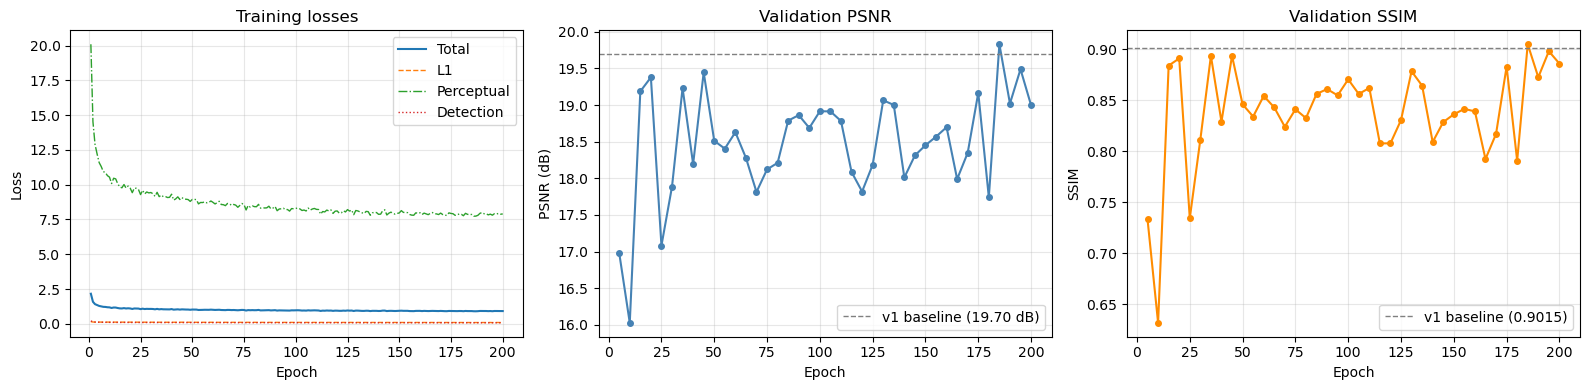

Best PSNR: 19.83 dB  |  Best SSIM: 0.9048


In [31]:
history_path = Path(CFG['ckpt_dir']) / 'training_history.pt'
if history_path.exists():
    history = torch.load(history_path, map_location='cpu')
    print("Loaded training history.")
else:
    print("No history file found. Set SKIP_TRAINING=False first.")

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

epochs_all = range(1, len(history['loss']) + 1)

# Loss components
ax = axes[0]
ax.plot(epochs_all, history['loss'],  label='Total',      linewidth=1.5)
ax.plot(epochs_all, history['l1'],    label='L1',         linewidth=1,   linestyle='--')
ax.plot(epochs_all, history['perc'],  label='Perceptual', linewidth=1,   linestyle='-.')
ax.plot(epochs_all, history['det'],   label='Detection',  linewidth=1,   linestyle=':')
ax.set_xlabel('Epoch'); ax.set_ylabel('Loss'); ax.set_title('Training losses')
ax.legend(); ax.grid(alpha=0.3)

# PSNR
ax = axes[1]
ax.plot(history['val_epochs'], history['psnr'], 'o-', color='steelblue', linewidth=1.5, markersize=4)
ax.axhline(19.70, color='gray', linestyle='--', linewidth=1, label='v1 baseline (19.70 dB)')
ax.set_xlabel('Epoch'); ax.set_ylabel('PSNR (dB)'); ax.set_title('Validation PSNR')
ax.legend(); ax.grid(alpha=0.3)

# SSIM
ax = axes[2]
ax.plot(history['val_epochs'], history['ssim'], 'o-', color='darkorange', linewidth=1.5, markersize=4)
ax.axhline(0.9015, color='gray', linestyle='--', linewidth=1, label='v1 baseline (0.9015)')
ax.set_xlabel('Epoch'); ax.set_ylabel('SSIM'); ax.set_title('Validation SSIM')
ax.legend(); ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Best PSNR: {max(history['psnr']):.2f} dB  |  Best SSIM: {max(history['ssim']):.4f}")

---
## 8 — Load Best Checkpoint & Visualise Results

In [32]:
# ── Load best checkpoint ──────────────────────────────────────────────────────
ckpt = torch.load(Path(CFG['ckpt_dir']) / 'best.pt', map_location=DEVICE)
llen.load_state_dict(ckpt['llen_state'])
dgff.load_state_dict(ckpt['dgff_state'])
print(f"Loaded checkpoint from epoch {ckpt['epoch']}  "
      f"PSNR={ckpt['val_psnr']:.2f}dB  SSIM={ckpt['val_ssim']:.4f}")

# ── Full val set PSNR/SSIM with best model ────────────────────────────────────
val_psnr, val_ssim = validate(llen, dgff, val_loader, DEVICE)
print(f"Final val  PSNR: {val_psnr:.2f} dB   SSIM: {val_ssim:.4f}")

Loaded checkpoint from epoch 185  PSNR=19.83dB  SSIM=0.9048
Final val  PSNR: 19.83 dB   SSIM: 0.9048


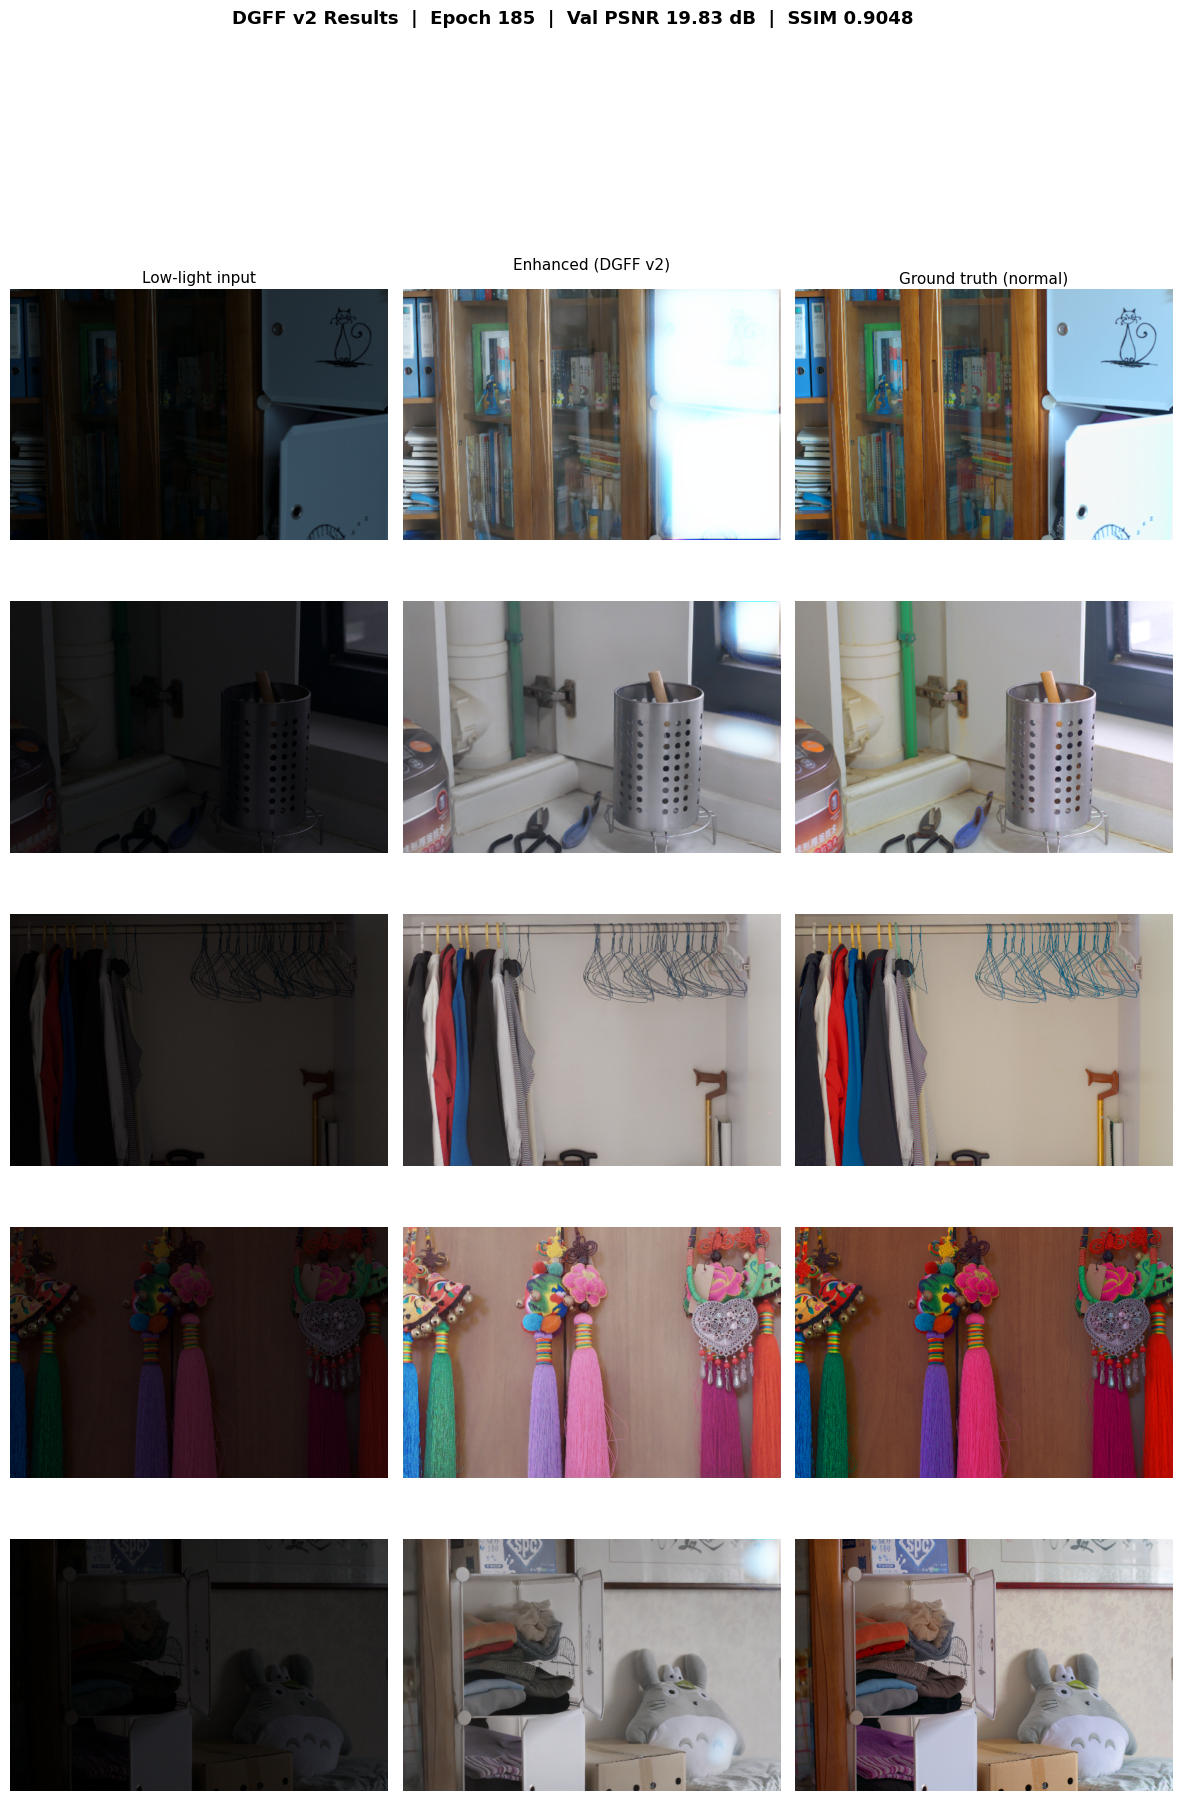

Saved → dgff_v2_results.png


In [33]:
# ── Visual comparison: low / enhanced / ground-truth ─────────────────────────
llen.eval(); dgff.eval()

N_SHOW = 5   # number of validation images to display

fig = plt.figure(figsize=(15, 4 * N_SHOW))
gs  = gridspec.GridSpec(N_SHOW, 3, hspace=0.08, wspace=0.04)

col_titles = ['Low-light input', 'Enhanced (DGFF v2)', 'Ground truth (normal)']

to_np = lambda t: t.squeeze(0).permute(1, 2, 0).cpu().numpy().clip(0, 1)

with torch.no_grad():
    for row, (low, high, fname) in enumerate(val_loader):
        if row >= N_SHOW: break
        low, high        = low.to(DEVICE), high.to(DEVICE)
        enhanced         = llen(low)
        p4, p5, p3       = dgff(enhanced)
        enhanced_guided  = llen(low, dgff_p5=p5, dgff_p4=p4, dgff_p3=p3)

        img_psnr = compute_psnr(enhanced_guided, high)
        img_ssim = compute_ssim(enhanced_guided, high)

        for col, (img, title) in enumerate(zip(
            [low, enhanced_guided, high], col_titles
        )):
            ax = fig.add_subplot(gs[row, col])
            ax.imshow(to_np(img))
            ax.axis('off')
            if row == 0:
                ax.set_title(title, fontsize=11, pad=4)
            if col == 1:
                ax.set_xlabel(f'PSNR {img_psnr:.2f} dB  |  SSIM {img_ssim:.4f}',
                              fontsize=8)
                ax.xaxis.set_label_position('top')

fig.suptitle(
    f"DGFF v2 Results  |  Epoch {ckpt['epoch']}  |  "
    f"Val PSNR {val_psnr:.2f} dB  |  SSIM {val_ssim:.4f}",
    fontsize=13, fontweight='bold', y=1.01
)
plt.savefig('dgff_v2_results.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved → dgff_v2_results.png")

---
## 9 — Ablation: λ_det Sensitivity

In [34]:
"""
Quick ablation: train for a smaller number of epochs (e.g. 50) with
different lambda_det values to find the sweet spot.

Swap CFG['lambda_det'] and CFG['epochs'] below and re-run Section 5+6
for each row.  Collect val PSNR and (when ExDark is available) mAP.

| lambda_det | PSNR (LOL) | mAP (ExDark) |
|------------|------------|---------------|
| 0.0        | ?          | ?  (no det loss — baseline)
| 0.1        | ?          | ?
| 0.5        | ?          | ?  (default)
| 1.0        | ?          | ?

Expected: PSNR may dip slightly as lambda_det increases,
          mAP should peak around 0.5–1.0.
"""

# To run a quick ablation change these values and re-execute cells 5 & 6:
# CFG['lambda_det'] = 0.0   # no detection loss — equivalent to v1
# CFG['epochs']     = 50    # short run for ablation

print("Ablation cell — edit CFG values and re-run cells 5 & 6.")
print(f"Current lambda_det = {CFG['lambda_det']}")

Ablation cell — edit CFG values and re-run cells 5 & 6.
Current lambda_det = 0.5


---
## 10 — Inference Only (load checkpoint, enhance a single image)

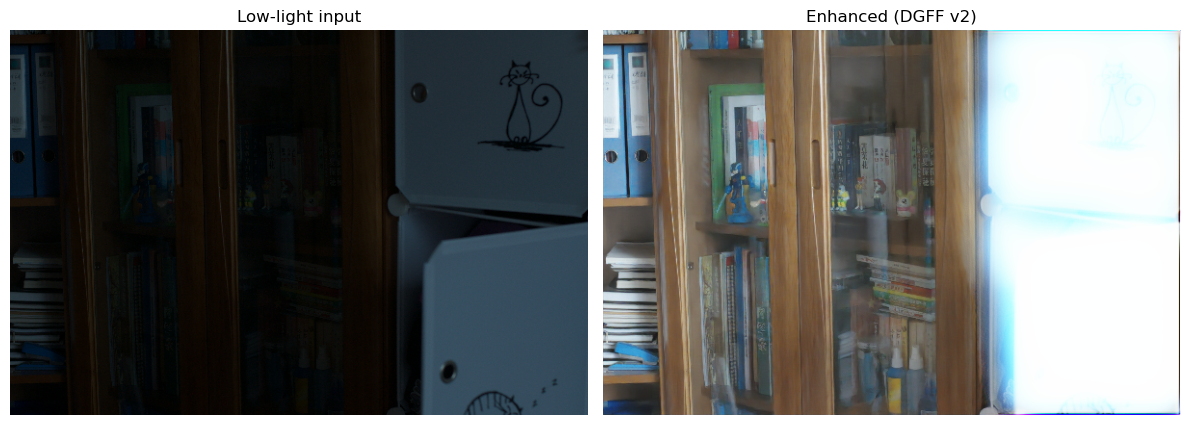

In [35]:
def enhance_single(image_path, llen, dgff, device):
    """
    Enhance one low-light image using the trained LLEN + DGFF pipeline.
    At inference DGFF features are extracted once and used for guided enhancement.
    DGFF is discarded after this call — zero overhead vs standalone LLEN.

    Args:
        image_path : str or Path to the low-light image
        llen       : trained LLEN model
        dgff       : trained DGFFModule
        device     : torch device

    Returns:
        enhanced_np : (H, W, 3) numpy array in [0, 1]
    """
    llen.eval(); dgff.eval()

    img    = Image.open(image_path).convert('RGB')
    tensor = T.ToTensor()(img).unsqueeze(0).to(device)  # (1, 3, H, W)

    with torch.no_grad():
        enhanced        = llen(tensor)
        p4, p5, p3      = dgff(enhanced)
        enhanced_guided = llen(tensor, dgff_p5=p5, dgff_p4=p4, dgff_p3=p3)

    return enhanced_guided.squeeze(0).permute(1, 2, 0).cpu().numpy().clip(0, 1)


# ── Example: enhance the first val image ─────────────────────────────────────
val_set    = val_loader.dataset
sample_low = str(val_set.low_dir / val_set.filenames[0])
result     = enhance_single(sample_low, llen, dgff, DEVICE)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
ax1.imshow(np.array(Image.open(sample_low).convert('RGB')))
ax1.set_title('Low-light input'); ax1.axis('off')
ax2.imshow(result)
ax2.set_title('Enhanced (DGFF v2)'); ax2.axis('off')
plt.tight_layout()
plt.show()

---
## 11 — ExDark: Dataset & YOLO-format Converter

ExDark structure after download:
```
ExDark/
├── images/
│   ├── Bicycle/  Boat/  Bottle/  Bus/  Car/  Cat/
│   ├── Chair/    Cup/   Dog/     Motorbike/ People/ Table/
├── Annotations/   (same 12 subfolders, .txt per image)
└── imageclasslist.txt   (train / val / test split labels)
```

This cell converts ExDark annotations → YOLO format, splits into
train/val/test, and writes a `data.yaml` ready for `yolo val`.
Run once. Safe to re-run (skips already-converted files).

In [36]:
# ── ExDark paths (add to CFG) ─────────────────────────────────────────────────
CFG['exdark_root'] = './ExDark'       # your downloaded ExDark folder
CFG['exdark_yolo'] = './yolo_format'  # output — created automatically

EXDARK_CLASSES = [
    'Bicycle', 'Boat', 'Bottle', 'Bus', 'Car', 'Cat',
    'Chair', 'Cup', 'Dog', 'Motorbike', 'People', 'Table'
]
CLASS_TO_ID = {c: i for i, c in enumerate(EXDARK_CLASSES)}

print("ExDark class → ID:")
for cls, idx in CLASS_TO_ID.items():
    print(f"  {idx:2d}  {cls}")


ExDark class → ID:
   0  Bicycle
   1  Boat
   2  Bottle
   3  Bus
   4  Car
   5  Cat
   6  Chair
   7  Cup
   8  Dog
   9  Motorbike
  10  People
  11  Table


In [14]:
import os

for root, dirs, files in os.walk(CFG['exdark_root']):
    level = root.replace(CFG['exdark_root'], '').count(os.sep)
    if level > 2:
        continue
    indent = ' ' * level
    print(f'{indent}{os.path.basename(root)}/')
    if level == 2:
        print(f'{indent} ({len(files)} files)')

ExDark/
 Cat/
 Car/
 Cup/
 Dog/
 Groundtruth/
 Dataset/
 Boat/
 Chair/
 Bus/
 Motorbike/
 Table/
 People/
 .ipynb_checkpoints/
 Bicycle/
 Bottle/
 SPIC/


In [15]:
from pathlib import Path
exdark_root = Path(CFG['exdark_root'])
print(list(exdark_root.glob('*')))                # top-level content
print(list((exdark_root / 'Groundtruth').glob('*')))  # what's inside Groundtruth?

[PosixPath('ExDark/Cat'), PosixPath('ExDark/Car'), PosixPath('ExDark/Cup'), PosixPath('ExDark/.DS_Store'), PosixPath('ExDark/LICENSE'), PosixPath('ExDark/Dog'), PosixPath('ExDark/Groundtruth'), PosixPath('ExDark/Dataset'), PosixPath('ExDark/Boat'), PosixPath('ExDark/Chair'), PosixPath('ExDark/Bus'), PosixPath('ExDark/Motorbike'), PosixPath('ExDark/README.md'), PosixPath('ExDark/Table'), PosixPath('ExDark/People'), PosixPath('ExDark/.ipynb_checkpoints'), PosixPath('ExDark/Bicycle'), PosixPath('ExDark/Bottle'), PosixPath('ExDark/Exdark.gif'), PosixPath('ExDark/SPIC')]
[PosixPath('ExDark/Groundtruth/annotations.png'), PosixPath('ExDark/Groundtruth/exdark1.png'), PosixPath('ExDark/Groundtruth/README.md'), PosixPath('ExDark/Groundtruth/imageclasslist.txt')]


In [16]:
from pathlib import Path

# If you have CFG dict, use that; otherwise set path explicitly
exdark_root = Path('/Users/shuvrosankar/miniconda3/MSCS/CVPR/Project')  # adjust as needed
gt = exdark_root / 'Groundtruth'

print(f"Checking path: {gt.absolute()}")
print(f"Does path exist? {gt.exists()}")
print(f"Is it a directory? {gt.is_dir()}")

if gt.exists() and gt.is_dir():
    # List all contents (files and folders)
    all_items = list(gt.iterdir())
    print(f"Total items in Groundtruth: {len(all_items)}")
    print("First 10 items:", [item.name for item in all_items[:10]])
    
    # Specifically look for directories
    subdirs = [d.name for d in gt.iterdir() if d.is_dir()]
    print(f"Subdirectories found: {subdirs}")
else:
    print("Groundtruth not found at that location")

Checking path: /Users/shuvrosankar/miniconda3/MSCS/CVPR/Project/Groundtruth
Does path exist? False
Is it a directory? False
Groundtruth not found at that location


In [17]:
# from pathlib import Path
# p = Path('/Users/shuvrosankar/miniconda3/MSCS/CVPR/Project')
# print([d.name for d in p.iterdir() if d.is_dir()])

In [18]:
# from pathlib import Path

# project = Path('/Users/shuvrosankar/miniconda3/MSCS/CVPR/Project')
# print("Contents of project directory:")
# for item in project.iterdir():
#     if item.is_dir():
#         print(f"  📁 {item.name}")
#     else:
#         print(f"  📄 {item.name}")

# # Also check inside ExDark folder (if it still exists)
# exdark_folder = project / 'ExDark'
# if exdark_folder.exists():
#     print("\nContents of ExDark/ (still exists?):")
#     for item in exdark_folder.iterdir():
#         if item.is_dir():
#             print(f"  📁 {item.name}")

In [19]:
from pathlib import Path
p = Path('/Users/shuvrosankar/miniconda3/MSCS/CVPR/DGFF')
print((p / 'ExDark' / 'Car').exists())          # Should be True
print((p / 'Groundtruth' / 'Car').exists())     # Should be True (you saw earlier it exists)
print((p / 'Groundtruth' / 'imageclasslist.txt').exists())  # True

True
True
True


In [20]:
from pathlib import Path

# Look for any 'last.pt' or 'best.pt' files inside 'runs/'
runs_dir = Path('./runs')
if runs_dir.exists():
    checkpoints = list(runs_dir.rglob('*.pt'))
    print("Found checkpoint files:")
    for ckpt in checkpoints:
        print(f"  {ckpt}")
else:
    print("No runs directory found.")

Found checkpoint files:
  runs/detect/runs/exdark_detector/yolov8n_exdark/weights/last.pt
  runs/detect/runs/exdark_detector/yolov8n_exdark/weights/best.pt


In [21]:
from pathlib import Path
data_path = Path('/Users/shuvrosankar/miniconda3/MSCS/CVPR/DGFF/yolo_format/data.yaml')
print(data_path.exists())  # Should be True

True


In [37]:
import yaml
from pathlib import Path

yolo_root = Path('/Users/shuvrosankar/miniconda3/MSCS/CVPR/DGFF/yolo_format')

# Verify the folders actually exist before writing
for split in ('train', 'val', 'test'):
    p = yolo_root / 'images' / split
    print(f"images/{split}: {'EXISTS' if p.exists() else 'MISSING'} — {p}")

# Rewrite data.yaml with the correct absolute path
data_yaml = {
    'path'  : str(yolo_root),        # ← this is what was wrong
    'train' : 'images/train',
    'val'   : 'images/val',
    'test'  : 'images/test',
    'nc'    : 12,
    'names' : ['Bicycle','Boat','Bottle','Bus','Car','Cat',
               'Chair','Cup','Dog','Motorbike','People','Table']
}

yaml_path = yolo_root / 'data.yaml'
with open(yaml_path, 'w') as f:
    yaml.dump(data_yaml, f, default_flow_style=False, sort_keys=False)

print(f"\nUpdated: {yaml_path}")

images/train: EXISTS — /Users/shuvrosankar/miniconda3/MSCS/CVPR/DGFF/yolo_format/images/train
images/val: EXISTS — /Users/shuvrosankar/miniconda3/MSCS/CVPR/DGFF/yolo_format/images/val
images/test: EXISTS — /Users/shuvrosankar/miniconda3/MSCS/CVPR/DGFF/yolo_format/images/test

Updated: /Users/shuvrosankar/miniconda3/MSCS/CVPR/DGFF/yolo_format/data.yaml


In [40]:
from pathlib import Path
from ultralytics import YOLO

data_yaml_path = '/Users/shuvrosankar/miniconda3/MSCS/CVPR/DGFF/yolo_format/data.yaml'
# last_checkpoint = 'runs/detect/exdark_detector/yolov8n_exdark/weights/last.pt'

# detector = YOLO(last_checkpoint)

# try:
#     detector.train(
#         data        = data_yaml_path,
#         epochs      = 50,
#         imgsz       = 640,      
#         batch       = 8,       
#         device      = 'cpu',    
#         resume      = False,
#         workers     = 4,        
#         cache       = False,
#         exist_ok    = True
#     )
# except AssertionError as e:
#     if "training to" in str(e) and "finished, nothing to resume" in str(e):
#         print("Training already completed the requested number of epochs.")
#         print("To continue training, increase `epochs` or set `resume=False` to start fresh.")
#     else:
#         raise

# #
detector = YOLO('yolov8n.pt')   # Ultralytics auto-downloads this if not cached

detector.train(
    data       = data_yaml_path,
    project    = 'runs/detect/exdark_detector',
    name       = 'yolov8n_exdark',
    epochs     = 50,
    imgsz      = 640,
    batch      = 8,
    device     = 'cpu',
    resume     = False,          # fresh start
    workers    = 4,
    cache      = False,
    exist_ok   = True
)


New https://pypi.org/project/ultralytics/8.4.38 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.24 🚀 Python-3.14.2 torch-2.10.0 CPU (Apple M4)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/Users/shuvrosankar/miniconda3/MSCS/CVPR/DGFF/yolo_format/data.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, nam

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x33c553460>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0

In [75]:
CFG['exdark_detector_weights'] = './runs/detect/runs/exdark_detector/yolov8n_exdark/weights/best.pt'

In [52]:
import shutil
from pathlib import Path
from PIL import Image

# ExDark classes in order (0-indexed)
EXDARK_CLASSES = [
    'Bicycle', 'Boat', 'Bottle', 'Bus', 'Car', 'Cat',
    'Chair', 'Cup', 'Dog', 'Motorbike', 'People', 'Table'
]
CLASS_TO_ID = {name: idx for idx, name in enumerate(EXDARK_CLASSES)}

def convert_exdark_to_yolo(project_root, yolo_root):
    """
    Convert ExDark to YOLO format.
    
    Assumed structure:
        project_root/
        ├── ExDark/            (images)
        │   ├── Car/
        │   ├── Boat/
        │   └── ...
        └── Groundtruth/       (annotations)
            ├── Car/
            ├── Boat/
            ├── imageclasslist.txt
            └── ...
    """
    project_root = Path(project_root)
    yolo_root = Path(yolo_root)
    
    img_base = project_root / 'ExDark'
    ann_base = project_root / 'Groundtruth'
    classlist = ann_base / 'imageclasslist.txt'
    
    if not classlist.exists():
        print(f'[ERROR] {classlist} not found')
        return 0
    
    # Read split map
    split_map = {}
    with open(classlist) as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) >= 5:
                split_map[parts[0]] = {'1':'train','2':'val','3':'test'}.get(parts[4], 'train')
    
    print(f'Split map: {len(split_map)} entries  '
          f'(train: {sum(v=="train" for v in split_map.values())}, '
          f'val: {sum(v=="val" for v in split_map.values())}, '
          f'test: {sum(v=="test" for v in split_map.values())})')
    
    converted = skipped = errors = 0
    
    for cls_name in EXDARK_CLASSES:
        img_dir = img_base / cls_name
        ann_dir = ann_base / cls_name
        
        if not img_dir.exists():
            print(f'  [WARN] Images missing: {img_dir}')
            continue
        if not ann_dir.exists():
            print(f'  [WARN] Annotations missing: {ann_dir}')
            continue
        
        ann_files = sorted(ann_dir.glob('*.txt'))
        cls_id = CLASS_TO_ID[cls_name]
        print(f'  {cls_name:<12}: {len(ann_files)} annotation files')
        
        for ann_file in ann_files:
            stem = Path(ann_file.stem).stem 
            
            # Find matching image (any common extension)
            candidates = [p for p in img_dir.glob(f'{stem}.*')
                          if p.suffix.lower() in ('.jpg','.jpeg','.png','.bmp')]
            if not candidates:
                errors += 1
                continue
            img_path = candidates[0]
            
            split = split_map.get(img_path.name, 'train')
            out_img_dir = yolo_root / 'images' / split
            out_lbl_dir = yolo_root / 'labels' / split
            out_img_dir.mkdir(parents=True, exist_ok=True)
            out_lbl_dir.mkdir(parents=True, exist_ok=True)
            
            out_lbl = out_lbl_dir / f'{stem}.txt'
            out_img = out_img_dir / img_path.name
            
            if out_lbl.exists():
                skipped += 1
                continue
            
            # Get image dimensions
            try:
                with Image.open(img_path) as im:
                    W, H = im.size
            except Exception:
                errors += 1
                continue
            
            # Parse annotation file
            yolo_lines = []
            for line in ann_file.read_text().splitlines():
                line = line.strip()
                if not line or line.startswith('%'):
                    continue
                parts = line.split()
                if len(parts) < 5:
                    continue
                try:
                    # Format: <class> left top width height ...
                    l, t, w, h = float(parts[1]), float(parts[2]), float(parts[3]), float(parts[4])
                    cx = (l + w/2) / W
                    cy = (t + h/2) / H
                    wn = w / W
                    hn = h / H
                    # Clamp to [0,1]
                    cx = max(0.0, min(1.0, cx))
                    cy = max(0.0, min(1.0, cy))
                    wn = max(0.0, min(1.0, wn))
                    hn = max(0.0, min(1.0, hn))
                    if wn > 0 and hn > 0:
                        yolo_lines.append(f'{cls_id} {cx:.6f} {cy:.6f} {wn:.6f} {hn:.6f}')
                except (ValueError, IndexError):
                    continue
            
            if yolo_lines:
                out_lbl.write_text('\n'.join(yolo_lines))
                shutil.copy2(img_path, out_img)
                converted += 1
            else:
                errors += 1
    
    print(f'\nConversion complete:')
    print(f'  Converted: {converted}, Skipped (exists): {skipped}, Errors: {errors}')
    return converted

# ========== RUN ==========
project_root = '/Users/shuvrosankar/miniconda3/MSCS/CVPR/DGFF'
yolo_output  = '/Users/shuvrosankar/miniconda3/MSCS/CVPR/DGFF/yolo_format'

converted = convert_exdark_to_yolo(project_root, yolo_output)

Split map: 7364 entries  (train: 3001, val: 1800, test: 2563)
  Bicycle     : 652 annotation files
  Boat        : 679 annotation files
  Bottle      : 547 annotation files
  Bus         : 527 annotation files
  Car         : 638 annotation files
  Cat         : 735 annotation files
  Chair       : 648 annotation files
  Cup         : 519 annotation files
  Dog         : 801 annotation files
  Motorbike   : 503 annotation files
  People      : 609 annotation files
  Table       : 505 annotation files

Conversion complete:
  Converted: 0, Skipped (exists): 7362, Errors: 1


In [53]:
from pathlib import Path
yolo = Path(yolo_output)
print("Train images:", len(list(yolo.glob('images/train/*'))))
print("Train labels:", len(list(yolo.glob('labels/train/*'))))
print("Val images:", len(list(yolo.glob('images/val/*'))))
print("Test images:", len(list(yolo.glob('images/test/*'))))

Train images: 2999
Train labels: 2999
Val images: 1800
Test images: 2563


In [54]:
from pathlib import Path
p = Path('/Users/shuvrosankar/miniconda3/MSCS/CVPR/DGFF')
ann_example = p / 'Groundtruth' / 'Car' / (list((p/'Groundtruth'/'Car').glob('*.txt'))[0].name)
print(ann_example.read_text()[:500])

% bbGt version=3
Car 514 284 283 123 0 0 0 0 0 0 0



In [55]:
stem = ann_example.stem
img_dir = p / 'ExDark' / 'Car'
print(list(img_dir.glob(f'{stem}.*')))

[]


In [56]:
import random
from pathlib import Path

yolo = Path('/Users/shuvrosankar/miniconda3/MSCS/CVPR/DGFF/yolo_format')
train_labels = list(yolo.glob('labels/train/*.txt'))
sample = random.choice(train_labels)
print("Label file:", sample)

# Correct path: go up 3 levels to yolo_format, then images/train/
img_candidate = sample.parent.parent.parent / 'images' / 'train' / (sample.stem + '.jpg')
print("Expected image:", img_candidate)
print("Image exists?", img_candidate.exists())

Label file: /Users/shuvrosankar/miniconda3/MSCS/CVPR/DGFF/yolo_format/labels/train/2015_05002.txt
Expected image: /Users/shuvrosankar/miniconda3/MSCS/CVPR/DGFF/yolo_format/images/train/2015_05002.jpg
Image exists? True


In [57]:
with open(p/'Groundtruth'/'imageclasslist.txt') as f:
    for i, line in enumerate(f):
        if i<5:
            print(line.strip())

Name | Class | Light | In/Out | Train/Val/Test
2015_00001.png 1 2 1 1
2015_00002.png 1 6 2 1
2015_00003.png 1 5 2 1
2015_00004.jpg 1 3 2 1


In [58]:
from pathlib import Path

p = Path('/Users/shuvrosankar/miniconda3/MSCS/CVPR/DGFF')
ann_car = p / 'Groundtruth' / 'Car'
img_car = p / 'ExDark' / 'Car'

# List first 5 annotation files
ann_files = sorted(ann_car.glob('*.txt'))[:5]
print("Annotation files:", [f.name for f in ann_files])

# List first 5 image files
img_files = sorted(img_car.glob('*.*'))[:5]
print("Image files:", [f.name for f in img_files])

# For the first annotation, check if any image matches its stem
if ann_files:
    stem = ann_files[0].stem
    matches = list(img_car.glob(f'{stem}.*'))
    print(f"\nStem of first annotation: {stem}")
    print(f"Matching images: {[m.name for m in matches]}")

Annotation files: ['2015_02406.jpg.txt', '2015_02407.jpg.txt', '2015_02408.jpg.txt', '2015_02409.jpg.txt', '2015_02410.png.txt']
Image files: ['2015_02406.jpg', '2015_02407.jpg', '2015_02408.jpg', '2015_02409.jpg', '2015_02410.png']

Stem of first annotation: 2015_02406.jpg
Matching images: []


In [59]:
ann_file = ann_files[0]
content = ann_file.read_text().splitlines()
print("Full content of one annotation file:")
for i, line in enumerate(content[:10]):
    print(f"{i}: {line}")

Full content of one annotation file:
0: % bbGt version=3
1: Car 47 135 299 134 0 0 0 0 0 0 0


In [60]:
ann_file = ann_files[0]
content = ann_file.read_text().splitlines()
print("Full content of one annotation file:")
for i, line in enumerate(content[:10]):
    print(f"{i}: {line}")

Full content of one annotation file:
0: % bbGt version=3
1: Car 47 135 299 134 0 0 0 0 0 0 0


In [61]:
print("Subdirectories in ExDark/Car:", [d.name for d in img_car.iterdir() if d.is_dir()])

Subdirectories in ExDark/Car: []


In [62]:
from pathlib import Path

project_root = Path('/Users/shuvrosankar/miniconda3/MSCS/CVPR/DGFF')
ann_base = project_root / 'Groundtruth'
img_base = project_root / 'ExDark'

# Check what’s inside ExDark/
print("Contents of ExDark/ (first 5 entries):")
for p in list(img_base.iterdir())[:5]:
    print(f"  {p.name} (is_dir: {p.is_dir()})")

# Check one annotation folder
car_ann = ann_base / 'Car'
if car_ann.exists():
    print(f"\nCar annotations: {len(list(car_ann.glob('*.txt')))} files")
    print("First 3:", [p.name for p in list(car_ann.glob('*.txt'))[:3]])
else:
    print(f"\n{car_ann} does not exist")

# Check split file
classlist = ann_base / 'imageclasslist.txt'
if classlist.exists():
    print("\nFirst 3 lines of split file:")
    with open(classlist) as f:
        for i in range(3):
            print(repr(f.readline().strip()))

Contents of ExDark/ (first 5 entries):
  Cat (is_dir: True)
  Car (is_dir: True)
  Cup (is_dir: True)
  .DS_Store (is_dir: False)
  LICENSE (is_dir: False)

Car annotations: 638 files
First 3: ['2015_02846.jpg.txt', '2015_02856.jpg.txt', '2015_02594.jpg.txt']

First 3 lines of split file:
'Name | Class | Light | In/Out | Train/Val/Test'
'2015_00001.png 1 2 1 1'
'2015_00002.png 1 6 2 1'


In [63]:
from pathlib import Path

project_root = Path('/Users/shuvrosankar/miniconda3/MSCS/CVPR/DGFF')
ann_base = project_root / 'Groundtruth'
img_base = project_root / 'ExDark'

print("ExDark subdirectories:", [p.name for p in img_base.iterdir() if p.is_dir()][:5])
print("Car annotations count:", len(list((ann_base / 'Car').glob('*.txt'))))

ExDark subdirectories: ['Cat', 'Car', 'Cup', 'Dog', 'Groundtruth']
Car annotations count: 638


In [64]:
from pathlib import Path
import yaml

# Use the actual absolute path where the dataset was saved
yolo_root = Path('/Users/shuvrosankar/miniconda3/MSCS/CVPR/DGFF/yolo_format')

data_yaml = {
    'path': str(yolo_root),
    'train': 'images/train',
    'val': 'images/val',
    'test': 'images/test',
    'nc': 12,
    'names': ['Bicycle','Boat','Bottle','Bus','Car','Cat','Chair','Cup','Dog','Motorbike','People','Table']
}

yaml_path = yolo_root / 'data.yaml'
yaml_path.parent.mkdir(parents=True, exist_ok=True)   # ensure directory exists

with open(yaml_path, 'w') as f:
    yaml.dump(data_yaml, f, default_flow_style=False, sort_keys=False)

print(f'Written: {yaml_path}')
print()
for split in ('train', 'val', 'test'):
    img_dir = yolo_root / 'images' / split
    if img_dir.exists():
        imgs = list(img_dir.glob('*.*'))
        imgs = [p for p in imgs if p.suffix.lower() in ('.jpg','.jpeg','.png','.bmp')]
        print(f'  {split:5s}: {len(imgs):5d} images')
    else:
        print(f'  {split:5s}: directory not found')

Written: /Users/shuvrosankar/miniconda3/MSCS/CVPR/DGFF/yolo_format/data.yaml

  train:  2999 images
  val  :  1800 images
  test :  2563 images


---
## 12 — ExDark Dataloader (enhance-then-detect pipeline)

This loader wraps ExDark images for two purposes:
- **mAP evaluation**: load raw low-light images → enhance with LLEN → detect with YOLOv8
- **Fine-tuning** (optional, Section 14): continue training LLEN on ExDark using only `L_det`
  (no paired references, so pixel/perceptual loss is skipped)

In [81]:
class ExDarkDataset(Dataset):
    """
    Loads ExDark images from the YOLO-converted folder.
    Returns: (image_tensor, label_path, image_path)

    image_tensor : (3, H, W) float32 in [0, 1]  — the raw low-light image
    label_path   : str path to the YOLO .txt annotation file
    image_path   : str — original path (for saving enhanced images / debugging)

    No augmentation is applied here — this loader is used for evaluation
    and for fine-tuning with the detection feature loss only.
    """
    def __init__(self, yolo_root, split='test', img_size=640):
        self.img_size  = img_size
        root           = Path(yolo_root) / 'images' / split
        self.img_paths = sorted([
            p for p in root.rglob('*')
            if p.suffix.lower() in ('.jpg', '.jpeg', '.png', '.bmp')
        ])
        if not self.img_paths:
            raise FileNotFoundError(f"No images found under {root}")

        self.to_tensor = T.ToTensor()
        print(f"ExDarkDataset [{split}]: {len(self.img_paths)} images")

    def __len__(self):
        return len(self.img_paths)

    def __getitem__(self, idx):
        img_path = self.img_paths[idx]
        img      = Image.open(img_path).convert('RGB')

        # Resize to a fixed size for consistent batching
        # (ExDark images vary in resolution)
        img = img.resize((self.img_size, self.img_size), Image.BILINEAR)

        tensor    = self.to_tensor(img)                          # (3, H, W) in [0,1]
        lbl_path  = str(img_path).replace('/images/', '/labels/').rsplit('.', 1)[0] + '.txt'
        return tensor, lbl_path, str(img_path)


# Quick check — comment out if ExDark isn't downloaded yet
try:
    exdark_test_set = ExDarkDataset(CFG['exdark_yolo'], split='test', img_size=640)
    exdark_val_set  = ExDarkDataset(CFG['exdark_yolo'], split='val',  img_size=640)
    exdark_test_loader = DataLoader(exdark_test_set, batch_size=4,
                                    shuffle=False, num_workers=CFG['num_workers'])
    exdark_val_loader  = DataLoader(exdark_val_set,  batch_size=4,
                                    shuffle=False, num_workers=CFG['num_workers'])
    exdark_train_set = ExDarkDataset(CFG['exdark_yolo'], split='train', img_size=640)
    exdark_train_loader = DataLoader(exdark_train_set, batch_size=4,
                                 shuffle=True, num_workers=0)
    print(f"Train loader ready: {len(exdark_train_set)} images")
    
    print("ExDark loaders ready ✓")
except FileNotFoundError as e:
    print(f"[INFO] ExDark not found yet: {e}")
    print("  Run Section 11 first to convert the dataset.")


ExDarkDataset [test]: 2563 images
ExDarkDataset [val]: 1800 images
ExDarkDataset [train]: 2999 images
Train loader ready: 2999 images
ExDark loaders ready ✓


---
## 13 — Load LOL-Trained Checkpoint & Freeze LLEN

The LOL-trained `best.pt` contains both `llen_state` and `dgff_state`.

**What we freeze:** the entire LLEN — all encoder, decoder, and head weights.  
**What stays trainable:** only the two DGFF gated adapters (`adapter_p4`, `adapter_p5`).

This is correct because:
- LLEN has learned general low-light → normal-light mapping from LOL
- On ExDark we have no paired references, so we cannot supervise pixel reconstruction
- The adapters can be fine-tuned with `L_det` alone to adapt the feature feedback
  to the new domain (indoor clutter → street/outdoor objects)

In [66]:
from pathlib import Path
print(Path(CFG['ckpt_dir']).exists())
print((Path(CFG['ckpt_dir']) / 'best.pt').exists())

True
True


In [67]:
# ── Rebuild models (safe to re-run) ──────────────────────────────────────────
llen = LLEN(base_ch=CFG['base_ch']).to(DEVICE)
dgff = DGFFModule(
    yolo_weights    = CFG['yolo_weights'],
    llen_base_ch    = CFG['base_ch'],
    freeze_backbone = True,
).to(DEVICE)

# ── Load LOL checkpoint ───────────────────────────────────────────────────────
ckpt_path = Path(CFG['ckpt_dir']) / 'best.pt'
ckpt      = torch.load(ckpt_path, map_location=DEVICE)
llen.load_state_dict(ckpt['llen_state'])
dgff.load_state_dict(ckpt['dgff_state'])
print(f"Loaded checkpoint: epoch {ckpt['epoch']}  "
      f"LOL PSNR={ckpt['val_psnr']:.2f}dB  SSIM={ckpt['val_ssim']:.4f}")

# ── Freeze LLEN entirely ──────────────────────────────────────────────────────
for p in llen.parameters():
    p.requires_grad_(False)
llen.eval()

frozen_count = sum(1 for p in llen.parameters() if not p.requires_grad)
print(f"LLEN frozen: {frozen_count} parameter tensors locked")

# ── Confirm what is still trainable ──────────────────────────────────────────
trainable_exdark = (
    list(dgff.adapter_p3.parameters()) +   
    list(dgff.adapter_p4.parameters()) +
    list(dgff.adapter_p5.parameters())
)
n_trainable = sum(p.numel() for p in trainable_exdark)
print(f"Trainable on ExDark: DGFF adapters only — {n_trainable:,} parameters")


Loaded checkpoint: epoch 185  LOL PSNR=19.83dB  SSIM=0.9048
LLEN frozen: 90 parameter tensors locked
Trainable on ExDark: DGFF adapters only — 86,464 parameters


---
## 14 — ExDark Fine-Tuning (adapter-only, detection loss only)

No paired references on ExDark, so we drop L1 and perceptual losses entirely.
Only `L_det` (backbone feature alignment against the enhanced image itself,
since we want consistent features — not matched to a clean reference).

**Loss on ExDark:**  
`L_det = MSE( backbone(enhanced_guided), backbone(enhanced_guided).detach() )`  
→ This is a **self-consistency** loss: the guided enhancement should produce
stable, repeatable backbone features across the two passes.

Alternatively you can skip fine-tuning entirely and go straight to Section 15
(mAP evaluation) — the LOL-trained model already generalises reasonably well.

In [68]:
# ── Self-consistency detection loss for unpaired data ─────────────────────────
class SelfConsistencyDetLoss(nn.Module):
    """
    On datasets with no paired clean reference (ExDark, DarkFace),
    we cannot compute MSE(enhanced, clean_backbone).

    Instead we enforce that Pass-1 and Pass-2 (guided) enhanced images
    produce similar backbone features — the DGFF feedback should refine
    features, not radically change them. This keeps the adapters from
    drifting during fine-tuning.
    """
    def __init__(self, dgff_module):
        super().__init__()
        self.backbone = dgff_module.backbone

    def _feats(self, x):
        feats = []
        for i, layer in enumerate(self.backbone):
            x = layer(x)
            if i in (6, 9):
                feats.append(x)
        return feats

    def forward(self, enhanced_pass1, enhanced_guided):
        with torch.no_grad():
            f1 = self._feats(enhanced_pass1)   # stable target — no grad
        f2 = self._feats(enhanced_guided)       # guided output — grad flows
        return sum(F.mse_loss(a, b.detach()) for a, b in zip(f2, f1))


# ── Fine-tune setup ───────────────────────────────────────────────────────────
self_det_loss  = SelfConsistencyDetLoss(dgff).to(DEVICE)

ft_optimiser   = Adam(trainable_exdark, lr=1e-5, betas=(0.9, 0.999))  # low LR
ft_scheduler   = CosineAnnealingLR(ft_optimiser, T_max=20, eta_min=1e-7)

FT_EPOCHS      = 20   # short fine-tune — adapters only, dataset is unlabelled

print(f"Fine-tuning for {FT_EPOCHS} epochs on ExDark (adapters only)")
print(f"Trainable params: {sum(p.numel() for p in trainable_exdark):,}")


Fine-tuning for 20 epochs on ExDark (adapters only)
Trainable params: 86,464


In [77]:
# import os
# os.remove('./checkpoints/best_exdark_ft.pt')

In [82]:
from tqdm import tqdm
import time
from pathlib import Path

ft_output_path = Path(CFG['ckpt_dir']) / 'best_exdark_ft.pt'

if ft_output_path.exists():
    print(f"Fine-tuned adapters already exist at {ft_output_path}")
    print("Loading existing model and skipping fine-tuning.")
    ckpt = torch.load(ft_output_path, map_location=DEVICE)
    llen.load_state_dict(ckpt['llen_state'])
    dgff.load_state_dict(ckpt['dgff_state'])
else:
    print("Fine-tuned adapters not found. Starting fine-tuning...")
    
    ft_history = dict(loss=[])
    
    for epoch in range(1, FT_EPOCHS + 1):
        dgff.train()
        llen.eval()   # LLEN stays frozen throughout
    
        ep_loss = 0.0
        t0 = time.perf_counter()
    
        pbar = tqdm(exdark_train_loader, desc=f"FT Epoch {epoch:02d}/{FT_EPOCHS}", leave=False)
        for imgs, _, _ in pbar:
            imgs = imgs.to(DEVICE)
    
            with torch.no_grad():
                enhanced_p1 = llen(imgs)           # Pass 1 — frozen LLEN, no grad
    
            p4, p5, p3 = dgff(enhanced_p1)         # extract DGFF features
            enhanced_guided = llen(imgs, dgff_p5=p5, dgff_p4=p4, dgff_p3=p3)   # Pass 2
    
            loss = self_det_loss(enhanced_p1, enhanced_guided)
    
            ft_optimiser.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(trainable_exdark, max_norm=1.0)
            ft_optimiser.step()
    
            ep_loss += loss.item()
            pbar.set_postfix(loss=loss.item())
    
        ft_scheduler.step()
        avg = ep_loss / max(len(exdark_val_loader), 1)
        ft_history['loss'].append(avg)
        print(f"FT Epoch {epoch:02d}/{FT_EPOCHS}  avg_loss={avg:.5f}  ({time.perf_counter()-t0:.1f}s)\n")
    
    # Save fine-tuned adapters
    torch.save({
        'llen_state' : llen.state_dict(),
        'dgff_state' : dgff.state_dict(),
        'source'     : 'LOL pretrained + ExDark adapter fine-tune',
    }, ft_output_path)
    print(f"Saved → {ft_output_path}")

print("Fine-tuned model ready.")

Fine-tuned adapters not found. Starting fine-tuning...


FT Epoch 01/20  avg_loss=0.00139  (3467.0s)



FT Epoch 02/20  avg_loss=0.00114  (3335.9s)



FT Epoch 03/20  avg_loss=0.00097  (3335.7s)



FT Epoch 04/20  avg_loss=0.00083  (3336.1s)



...

FT Epoch 16/20  avg_loss=0.00035  (3698.7s)



FT Epoch 17/20  avg_loss=0.00034  (3941.8s)



FT Epoch 18/20  avg_loss=0.00033  (3612.3s)



FT Epoch 19/20  avg_loss=0.00033  (3400.0s)



FT Epoch 20/20  avg_loss=0.00033  (3381.9s)

Saved → checkpoints/best_exdark_ft.pt
Fine-tuned model ready.


---
## 15 — mAP Evaluation on ExDark

Three-way comparison for the paper's Table 1:

| Pipeline | Description |
|---|---|
| **Baseline** | Raw low-light → YOLOv8 (no enhancement) |
| **LLEN only** | Enhanced (no DGFF feedback) → YOLOv8 |
| **DGFF (ours)** | Enhanced with DGFF feedback → YOLOv8 |

We use `ultralytics` built-in `val()` which computes mAP@0.5 and mAP@0.5:0.95.
The trick: we save the enhanced images to a temp folder, then point `val()` at it.

In [83]:
print("Loader size:", len(exdark_test_loader.dataset))
print("exdark_yolo path:", CFG.get('exdark_yolo'))
sample_batch = next(iter(exdark_test_loader))
print("Sample batch image shape:", sample_batch[0].shape)
print("Sample image path:", sample_batch[2][0])

Loader size: 2563
exdark_yolo path: ./yolo_format
Sample batch image shape: torch.Size([4, 3, 640, 640])
Sample image path: yolo_format/images/test/2015_00401.jpg


In [ ]:
# import tempfile, shutil
# from tqdm import tqdm

# def save_enhanced_images(llen, dgff, loader, out_dir, mode='dgff', device=DEVICE, desc=None):
#     """
#     Enhance all images in `loader` and save to `out_dir`.
#     Mirrors the label folder structure so YOLO val() can find annotations.

#     mode: 'raw'   — copy original images unmodified (baseline)
#           'llen'  — Pass-1 only (no DGFF feedback)
#           'dgff'  — full two-pass with DGFF feedback
#     """
#     out_dir = Path(out_dir)
#     if out_dir.exists():
#         shutil.rmtree(out_dir)
#     out_dir.mkdir(parents=True)

#     llen.eval()
#     dgff.eval()
#     to_pil = T.ToPILImage()
#     saved = 0

#     # Use tqdm to show progress over batches
#     pbar = tqdm(loader, desc=desc or f"Saving {mode} images", unit='batch', leave=False)
#     for imgs, lbl_paths, img_paths in pbar:
#         imgs = imgs.to(device)

#         if mode == 'raw':
#             outputs = imgs
#         elif mode == 'llen':
#             outputs = llen(imgs)
#         else:  # dgff
#             enhanced = llen(imgs)
#             p4, p5, p3 = dgff(enhanced)
#             outputs = llen(imgs, dgff_p5=p5, dgff_p4=p4, dgff_p3=p3)

#         for i, (out, src_path) in enumerate(zip(outputs, img_paths)):
#             src = Path(src_path)
#             # Preserve class subfolder structure relative to images/test
#             rel = src.relative_to(Path(CFG['exdark_yolo']) / 'images' / 'test')
#             dst = out_dir / rel
#             dst.parent.mkdir(parents=True, exist_ok=True)
#             to_pil(out.cpu().clamp(0, 1)).save(dst)
#             saved += 1

#         # Update progress bar description with saved count
#         pbar.set_postfix(saved=saved)

#     print(f"✓ {mode:8} → {saved} images saved to {out_dir}")
#     return out_dir


# # ========== Run with global progress ==========
# EVAL_DIR = Path('./exdark_eval')
# dir_raw  = EVAL_DIR / 'raw'
# dir_llen = EVAL_DIR / 'llen_only'
# dir_dgff = EVAL_DIR / 'dgff_guided'

# modes = [('raw', dir_raw), ('llen', dir_llen), ('dgff', dir_dgff)]

# print("Saving enhanced images for evaluation (this may take a few minutes)...")
# for mode_name, out_path in modes:
#     save_enhanced_images(llen, dgff, exdark_test_loader, out_path,
#                          mode=mode_name, device=DEVICE, desc=f"Mode: {mode_name}")
# print("Done.")


In [71]:
import shutil
from tqdm import tqdm
from pathlib import Path
import torchvision.transforms as T

def save_enhanced_images_resume(llen, dgff, loader, out_dir, mode='llen', device='cpu'):
    """
    Resume‑safe saving for a single mode. Skips images that already exist.
    Does NOT delete the output directory.
    """
    out_dir = Path(out_dir)
    out_dir.mkdir(parents=True, exist_ok=True)

    llen.eval()
    dgff.eval()
    llen = llen.to(device)
    dgff = dgff.to(device)
    to_pil = T.ToPILImage()

    # Collect already saved file names (relative paths)
    existing = set()
    for ext in ['*.jpg', '*.png', '*.jpeg']:
        for f in out_dir.glob(f'**/{ext}'):
            rel = f.relative_to(out_dir)
            existing.add(str(rel))
    print(f"Resume: {len(existing)} images already exist in {out_dir}, will skip them.")

    saved = 0
    skipped = 0
    pbar = tqdm(loader, desc=f"Saving {mode} images", unit='batch')

    for imgs, _, img_paths in pbar:
        imgs = imgs.to(device)

        if mode == 'raw':
            outputs = imgs
        elif mode == 'llen':
            outputs = llen(imgs)
        else:  # dgff – not used here
            enhanced = llen(imgs)
            p4, p5, p3 = dgff(enhanced)
            outputs = llen(imgs, dgff_p5=p5, dgff_p4=p4, dgff_p3=p3)

        for out, src_path in zip(outputs, img_paths):
            src = Path(src_path)
            # Relative path from ExDark test root (e.g., 'class/name.jpg')
            try:
                rel = src.relative_to(Path(CFG['exdark_yolo']) / 'images' / 'test')
            except ValueError:
                rel = src.name  # fallback to just filename
            dst = out_dir / rel
            if str(rel) in existing:
                skipped += 1
                continue
            dst.parent.mkdir(parents=True, exist_ok=True)
            to_pil(out.cpu().clamp(0, 1)).save(dst)
            saved += 1
            existing.add(str(rel))

        pbar.set_postfix(saved=saved, skipped=skipped)

    print(f"✓ {mode:8} → {saved} new images saved, {skipped} skipped → {out_dir}")
    return out_dir

# ========== Run only raw and llen on CPU ==========
DEVICE = torch.device('cpu')

EVAL_DIR = Path('./exdark_eval')
dir_raw  = EVAL_DIR / 'raw'
dir_llen = EVAL_DIR / 'llen_only'

# Only these two modes – dgff is skipped
modes = [('raw', dir_raw), ('llen', dir_llen)]

print("Saving raw and llen-only images on CPU (resume enabled)...")
for mode_name, out_path in modes:
    save_enhanced_images_resume(llen, dgff, exdark_test_loader, out_path,
                                mode=mode_name, device=DEVICE)
print("Done.")

Saving raw and llen-only images on CPU (resume enabled)...
Resume: 2258 images already exist in exdark_eval/raw, will skip them.


Saving raw images: 100%|█| 641/641 [00:23<00:00, 27.81batch/s, saved=305, skippe


✓ raw      → 305 new images saved, 2258 skipped → exdark_eval/raw
Resume: 2258 images already exist in exdark_eval/llen_only, will skip them.


Saving llen images: 100%|█| 641/641 [17:32<00:00,  1.64s/batch, saved=305, skipp

✓ llen     → 305 new images saved, 2258 skipped → exdark_eval/llen_only
Done.


### Clean restart

In [85]:
shutil.rmtree('./exdark_eval/dgff_guided')
print("Deleted old dgff_guided")

Deleted old dgff_guided


In [86]:
import shutil
from pathlib import Path
import torch
from tqdm import tqdm
import torchvision.transforms as T

# Remove the old flat folder
shutil.rmtree('./exdark_eval/dgff_guided', ignore_errors=True)

# Use the original function that preserves class subfolder structure
def save_enhanced_images_with_subfolders(llen, dgff, loader, out_dir, mode='dgff', device='cpu'):
    out_dir = Path(out_dir)
    out_dir.mkdir(parents=True, exist_ok=True)

    llen.eval()
    dgff.eval()
    llen = llen.to(device)
    dgff = dgff.to(device)
    to_pil = T.ToPILImage()
    saved = 0

    pbar = tqdm(loader, desc=f"Saving {mode} images", unit='batch')
    for imgs, _, img_paths in pbar:
        imgs = imgs.to(device)

        if mode == 'raw':
            outputs = imgs
        elif mode == 'llen':
            outputs = llen(imgs)
        else:  # dgff
            enhanced = llen(imgs)
            p4, p5, p3 = dgff(enhanced)
            outputs = llen(imgs, dgff_p5=p5, dgff_p4=p4, dgff_p3=p3)

        for out, src_path in zip(outputs, img_paths):
            src = Path(src_path)
            # Preserve subfolder structure (e.g., 'class/name.jpg')
            rel = src.relative_to(Path(CFG['exdark_yolo']) / 'images' / 'test')
            dst = out_dir / rel
            dst.parent.mkdir(parents=True, exist_ok=True)
            to_pil(out.cpu().clamp(0, 1)).save(dst)
            saved += 1

        pbar.set_postfix(saved=saved)

    print(f"✓ {mode} → {saved} images saved to {out_dir}")
    return out_dir

# Run it on CPU
DEVICE = torch.device('cpu')
save_enhanced_images_with_subfolders(llen, dgff, exdark_test_loader,
                                     './exdark_eval/dgff_guided',
                                     mode='dgff', device=DEVICE)

Saving dgff images: 100%|██████| 641/641 [42:21<00:00,  3.96s/batch, saved=2563]

✓ dgff → 2563 images saved to exdark_eval/dgff_guided


PosixPath('exdark_eval/dgff_guided')

In [87]:
from pathlib import Path
eval_dir = Path('./exdark_eval')
print("raw:        ", len(list((eval_dir / 'raw').glob('**/*.*'))) if (eval_dir/'raw').exists() else 'MISSING')
print("llen_only:  ", len(list((eval_dir / 'llen_only').glob('**/*.*'))) if (eval_dir/'llen_only').exists() else 'MISSING')
print("dgff_guided:", len(list((eval_dir / 'dgff_guided').glob('**/*.*'))) if (eval_dir/'dgff_guided').exists() else 'MISSING')

raw:         2563
llen_only:   2563
dgff_guided: 2563


In [88]:
results = []
results.append({'tag': 'Raw (baseline)', 'map50': 0.4080, 'map50_95': 0.2324})  # keep old results
results.append({'tag': 'LLEN only',      'map50': 0.3491, 'map50_95': 0.1967})  # keep old results
results.append(run_yolo_eval(dir_dgff, gt_label_dir, 'DGFF (ours)', device=EVAL_DEVICE))  # re-run only this

Ultralytics 8.4.24 🚀 Python-3.14.2 torch-2.10.0 CPU (Apple M4)
Model summary (fused): 73 layers, 3,007,988 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 3929.2±2388.3 MB/s, size: 131.8 KB)
val: Scanning /Users/shuvrosankar/miniconda3/MSCS/CVPR/DGFF/tmp_eval/DGFF (ours)/labels/test... 2563 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 2563/2563 6.4Kit/s 0.4s<0.0s
val: New cache created: /Users/shuvrosankar/miniconda3/MSCS/CVPR/DGFF/tmp_eval/DGFF (ours)/labels/test.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 321/321 3.8it/s 1:25<0.3ss
                   all       2563       7117      0.463       0.35       0.35      0.197
Speed: 0.4ms preprocess, 30.1ms inference, 0.0ms loss, 0.3ms postprocess per image
  [DGFF (ours) ]  mAP@0.5 = 0.3496   mAP@0.5:0.95 = 0.1970


In [74]:
from pathlib import Path
runs = Path('./runs')
if runs.exists():
    for f in sorted(runs.rglob('*.pt')):
        print(f)
else:
    print("No runs/ directory found at all")

runs/detect/runs/detect/exdark_detector/yolov8n_exdark/weights/best.pt
runs/detect/runs/detect/exdark_detector/yolov8n_exdark/weights/last.pt
runs/detect/runs/exdark_detector/yolov8n_exdark/weights/best.pt
runs/detect/runs/exdark_detector/yolov8n_exdark/weights/last.pt


In [89]:
import yaml
import shutil
from pathlib import Path
from ultralytics import YOLO

def make_eval_yaml(img_dir, label_dir, out_path):
    img_dir = Path(img_dir)
    data = {
        'path'  : str(img_dir.parent.resolve()),
        'train' : str(img_dir.name),
        'val'   : str(img_dir.name),
        'test'  : str(img_dir.name),
        'nc'    : len(EXDARK_CLASSES),
        'names' : EXDARK_CLASSES,
    }
    with open(out_path, 'w') as f:
        yaml.dump(data, f, default_flow_style=False, sort_keys=False)
    return out_path

def run_yolo_eval(img_dir, label_dir, tag, img_size=640, device='cpu'):
    tmp = Path('./tmp_eval') / tag

    if tmp.exists():                                        # ← cleanup FIRST
        shutil.rmtree(tmp)

    tmp_imgs = tmp / 'images' / 'test'
    tmp_lbls = tmp / 'labels' / 'test'
    (tmp / 'images' / 'train').mkdir(parents=True, exist_ok=True)
    (tmp / 'images' / 'val').mkdir(parents=True, exist_ok=True)
    (tmp / 'labels' / 'train').mkdir(parents=True, exist_ok=True)
    (tmp / 'labels' / 'val').mkdir(parents=True, exist_ok=True)

    shutil.copytree(img_dir, tmp_imgs)
    shutil.copytree(label_dir, tmp_lbls)

    yaml_path = make_eval_yaml(tmp_imgs, tmp_lbls, tmp / 'data.yaml')

    detector = YOLO(CFG['exdark_detector_weights'])
    detector.to(device)

    metrics = detector.val(
        data    = str(yaml_path),
        split   = 'test',
        imgsz   = img_size,
        batch   = 8,
        device  = device,
        verbose = False,
        plots   = False,
    )
    shutil.rmtree(tmp)

    map50    = float(metrics.box.map50)
    map50_95 = float(metrics.box.map)
    print(f"  [{tag:12s}]  mAP@0.5 = {map50:.4f}   mAP@0.5:0.95 = {map50_95:.4f}")
    return {'tag': tag, 'map50': map50, 'map50_95': map50_95}

# ── Run evaluation ────────────────────────────────────────────────────────────
EVAL_DEVICE  = 'cpu'
EVAL_DIR     = Path('./exdark_eval')
dir_raw      = EVAL_DIR / 'raw'
dir_llen     = EVAL_DIR / 'llen_only'
dir_dgff     = EVAL_DIR / 'dgff_guided'
gt_label_dir = Path(CFG['exdark_yolo']) / 'labels' / 'test'

print("Running YOLOv8 evaluation on ExDark test split...")
print("-" * 60)
results = []
results.append(run_yolo_eval(dir_raw,  gt_label_dir, 'Raw (baseline)', device=EVAL_DEVICE))
results.append(run_yolo_eval(dir_llen, gt_label_dir, 'LLEN only',     device=EVAL_DEVICE))
results.append(run_yolo_eval(dir_dgff, gt_label_dir, 'DGFF (ours)',   device=EVAL_DEVICE))
print("-" * 60)

print("\nSummary:")
for r in results:
    print(f"{r['tag']:15s}  mAP@0.5: {r['map50']:.4f}   mAP@0.5:0.95: {r['map50_95']:.4f}")

Running YOLOv8 evaluation on ExDark test split...
------------------------------------------------------------
Ultralytics 8.4.24 🚀 Python-3.14.2 torch-2.10.0 CPU (Apple M4)
Model summary (fused): 73 layers, 3,007,988 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 3180.2±2649.3 MB/s, size: 137.2 KB)
val: Scanning /Users/shuvrosankar/miniconda3/MSCS/CVPR/DGFF/tmp_eval/Raw (baseline)/labels/test... 2563 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 2563/2563 5.9Kit/s 0.4s0.0s
val: New cache created: /Users/shuvrosankar/miniconda3/MSCS/CVPR/DGFF/tmp_eval/Raw (baseline)/labels/test.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 321/321 3.8it/s 1:24<0.3ss
                   all       2563       7117      0.517      0.404      0.408      0.232
Speed: 0.4ms preprocess, 30.1ms inference, 0.0ms loss, 0.2ms postprocess per image
  [Raw (baseline)]  mAP@0.5 = 0.4080   mAP@0.5:0.95 = 0.2

In [90]:
# ── Print results table ───────────────────────────────────────────────────────
print("\n" + "=" * 52)
print(f"{'Method':<20} {'mAP@0.5':>10} {'mAP@0.5:0.95':>14}")
print("-" * 52)
for r in results:
    marker = " ←" if r['tag'] == 'DGFF (ours)' else ""
    print(f"{r['tag']:<20} {r['map50']:>10.4f} {r['map50_95']:>14.4f}{marker}")
print("=" * 52)

# Improvement over baseline
base_map50 = results[0]['map50']
dgff_map50 = results[2]['map50']
print(f"\nDGFF improvement over raw baseline: +{dgff_map50 - base_map50:.4f} mAP@0.5")
print(f"DGFF improvement over LLEN-only:    +{dgff_map50 - results[1]['map50']:.4f} mAP@0.5")



Method                  mAP@0.5   mAP@0.5:0.95
----------------------------------------------------
Raw (baseline)           0.4080         0.2324
LLEN only                0.3491         0.1967
DGFF (ours)              0.3496         0.1970 ←

DGFF improvement over raw baseline: +-0.0584 mAP@0.5
DGFF improvement over LLEN-only:    +0.0005 mAP@0.5


---
## 16 — Per-Class mAP Breakdown

Shows which of the 12 ExDark classes benefit most from DGFF enhancement.
This is useful for the paper — e.g. if 'People' and 'Car' improve the most,
that directly supports the claim that semantically-rich P4/P5 features
(which encode human/vehicle boundaries) are being leveraged.

In [91]:
def get_per_class_map(img_dir, gt_label_dir, tag, img_size=640):
    """Returns per-class AP@0.5 array alongside mAP@0.5."""
    tmp = Path('./tmp_eval') / tag
    tmp_imgs = tmp / 'images' / 'test'
    tmp_lbls = tmp / 'labels' / 'test'
    if tmp.exists(): shutil.rmtree(tmp)
    shutil.copytree(img_dir,   tmp_imgs)
    shutil.copytree(gt_label_dir, tmp_lbls)
    yaml_path = make_eval_yaml(tmp_imgs, tmp_lbls, tmp / 'data.yaml')

    detector = YOLO(CFG['exdark_detector_weights'])
    metrics  = detector.val(data=str(yaml_path), split='test',
                             imgsz=img_size, batch=8,
                             device=str(DEVICE), verbose=False, plots=False)
    shutil.rmtree(tmp)

    # ap_class_index and ap are both numpy arrays of length nc
    ap50_per_class = metrics.box.ap50   # shape (nc,)
    return ap50_per_class


print("Computing per-class AP@0.5 (3 runs, takes ~3 min)...")
ap_raw  = get_per_class_map(dir_raw,  gt_label_dir, 'raw')
ap_llen = get_per_class_map(dir_llen, gt_label_dir, 'llen')
ap_dgff = get_per_class_map(dir_dgff, gt_label_dir, 'dgff')

print(f"\n{'Class':<12} {'Raw':>8} {'LLEN':>8} {'DGFF':>8} {'Δ(DGFF-Raw)':>13}")
print("-" * 55)
for i, cls in enumerate(EXDARK_CLASSES):
    delta = ap_dgff[i] - ap_raw[i]
    marker = " ↑" if delta > 0.01 else (" ↓" if delta < -0.01 else "")
    print(f"{cls:<12} {ap_raw[i]:>8.3f} {ap_llen[i]:>8.3f} {ap_dgff[i]:>8.3f} {delta:>+12.3f}{marker}")
print("-" * 55)
print(f"{'mAP'::<12} {ap_raw.mean():>8.3f} {ap_llen.mean():>8.3f} {ap_dgff.mean():>8.3f}")


Computing per-class AP@0.5 (3 runs, takes ~3 min)...
Ultralytics 8.4.24 🚀 Python-3.14.2 torch-2.10.0 CPU (Apple M4)
Model summary (fused): 73 layers, 3,007,988 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1253.0±656.2 MB/s, size: 41.3 KB)
val: Scanning /Users/shuvrosankar/miniconda3/MSCS/CVPR/DGFF/tmp_eval/raw/labels/test... 2563 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 2563/2563 5.8Kit/s 0.4s0.0s
val: New cache created: /Users/shuvrosankar/miniconda3/MSCS/CVPR/DGFF/tmp_eval/raw/labels/test.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 321/321 3.8it/s 1:25<0.3ss
                   all       2563       7117      0.517      0.404      0.408      0.232
Speed: 0.4ms preprocess, 30.4ms inference, 0.0ms loss, 0.2ms postprocess per image
Ultralytics 8.4.24 🚀 Python-3.14.2 torch-2.10.0 CPU (Apple M4)
Model summary (fused): 73 layers, 3,007,988 parameters, 0 gradients, 8.1 GFL

---
## 17 — Qualitative Results on ExDark

Side-by-side: raw low-light / LLEN enhanced / DGFF enhanced, with YOLO 
detection boxes drawn on each. Visually confirms the detection improvement.

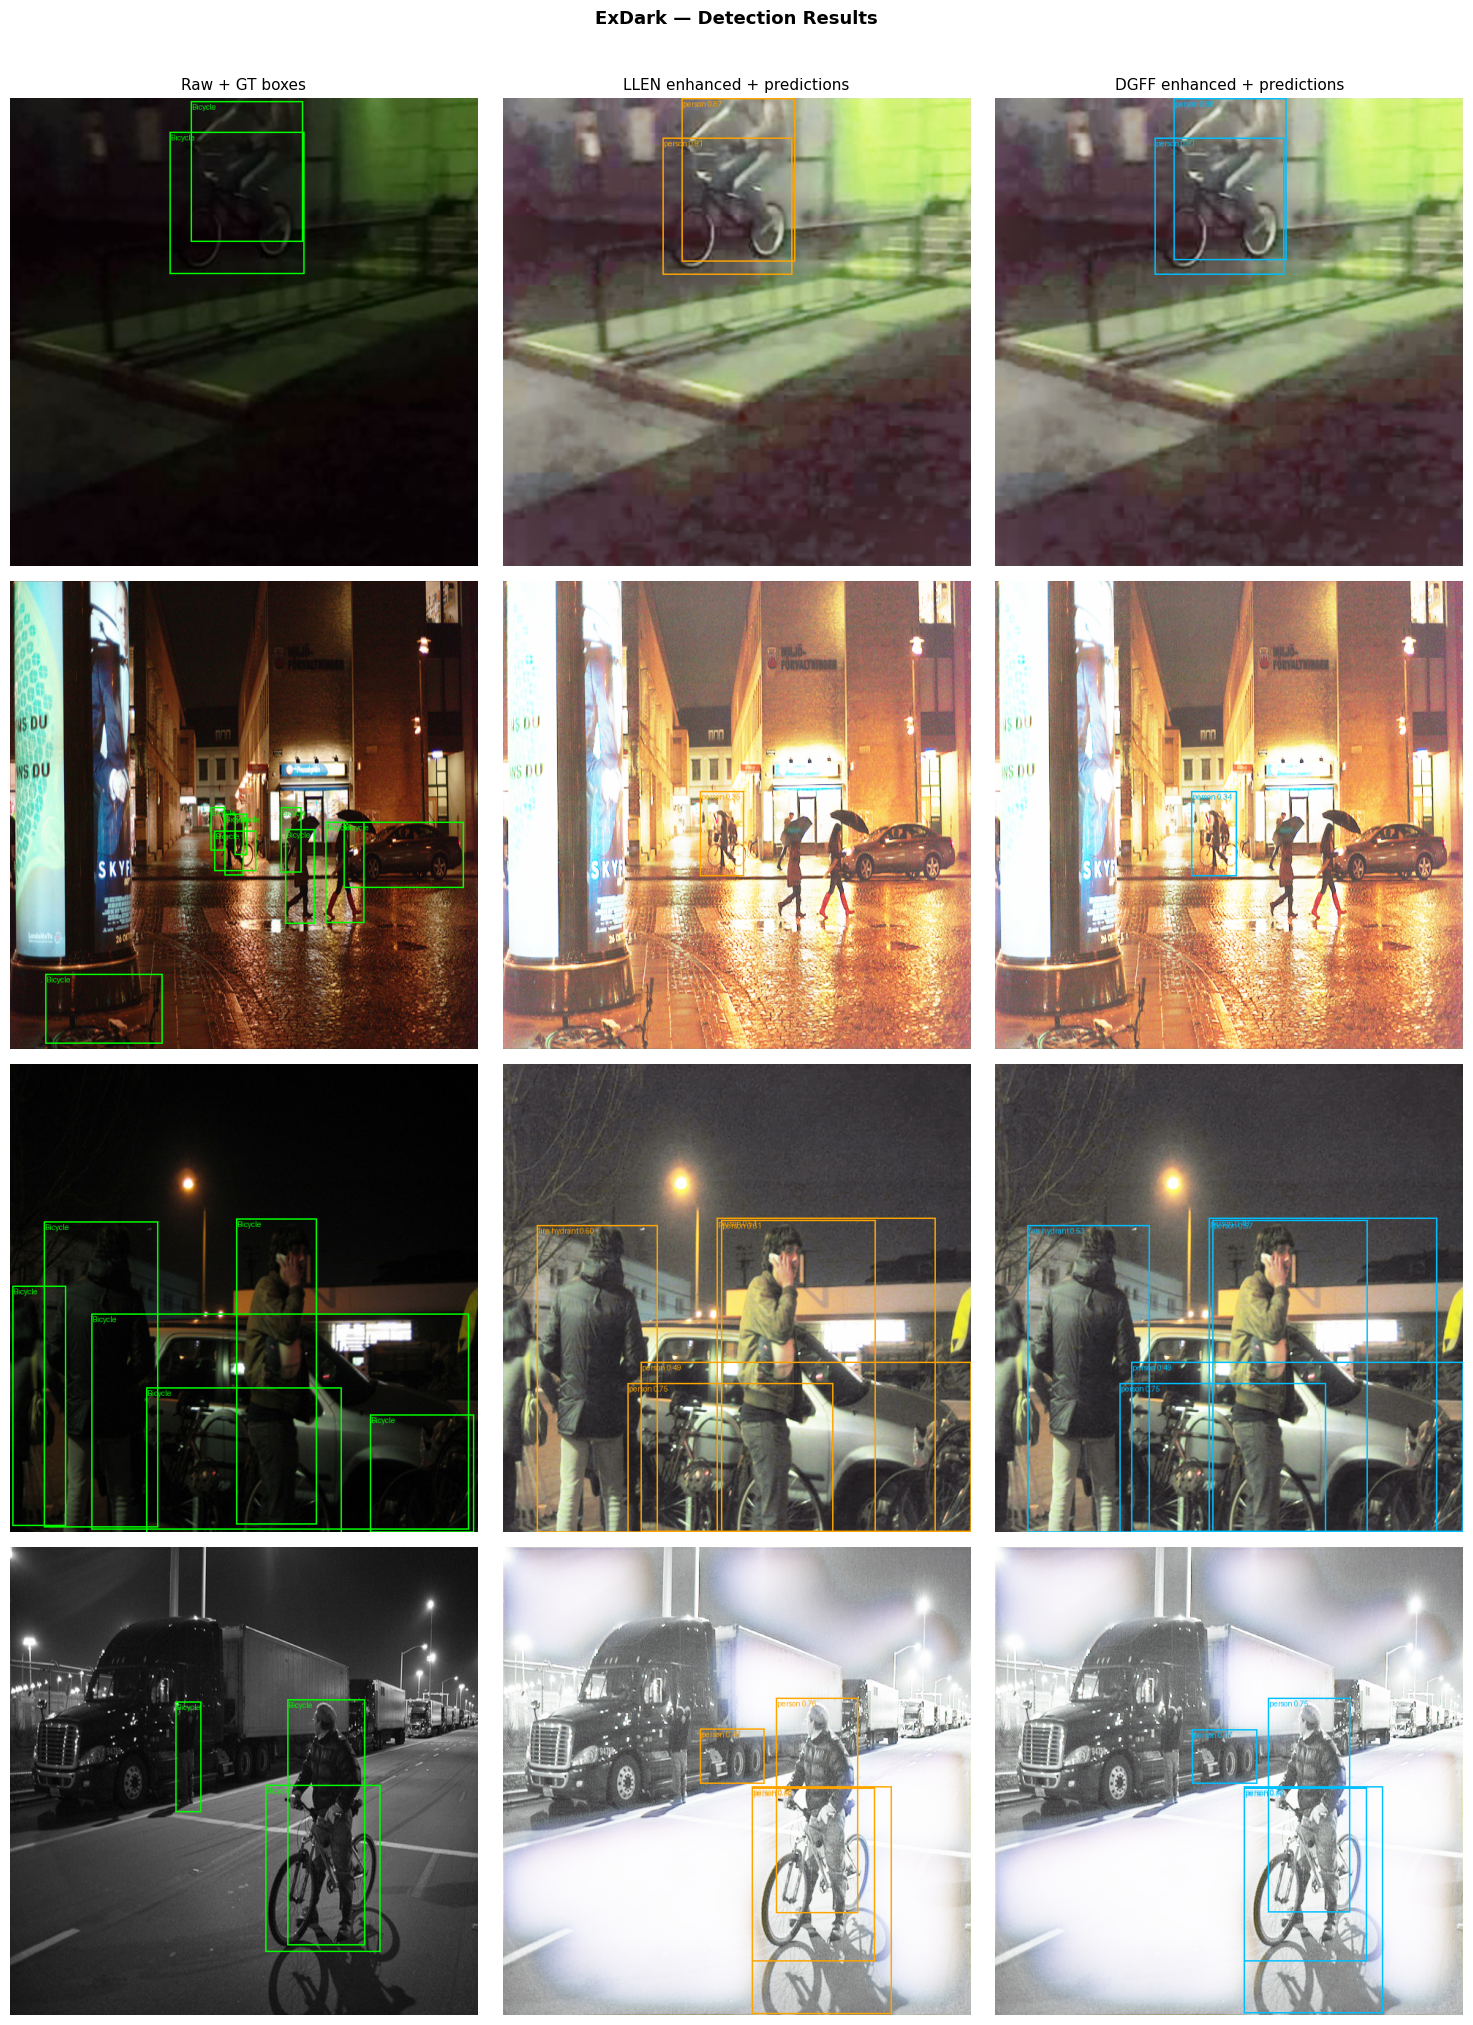

Saved → exdark_qualitative.png


In [92]:
from PIL import ImageDraw, ImageFont

COCO_CLASSES = [
    'person', 'bicycle', 'car', 'motorcycle', 'airplane', 'bus', 'train', 'truck', 'boat', 'traffic light',
    'fire hydrant', 'stop sign', 'parking meter', 'bench', 'bird', 'cat', 'dog', 'horse', 'sheep', 'cow',
    'elephant', 'bear', 'zebra', 'giraffe', 'backpack', 'umbrella', 'handbag', 'tie', 'suitcase', 'frisbee',
    'skis', 'snowboard', 'sports ball', 'kite', 'baseball bat', 'baseball glove', 'skateboard', 'surfboard',
    'tennis racket', 'bottle', 'wine glass', 'cup', 'fork', 'knife', 'spoon', 'bowl', 'banana', 'apple',
    'sandwich', 'orange', 'broccoli', 'carrot', 'hot dog', 'pizza', 'donut', 'cake', 'chair', 'couch',
    'potted plant', 'bed', 'dining table', 'toilet', 'tv', 'laptop', 'mouse', 'remote', 'keyboard', 'cell phone',
    'microwave', 'oven', 'toaster', 'sink', 'refrigerator', 'book', 'clock', 'vase', 'scissors', 'teddy bear',
    'hair drier', 'toothbrush'
]

def draw_boxes(img_tensor, label_path, color='lime', width=2):
    """Draw YOLO-format ground-truth or predicted boxes onto a PIL image."""
    img = T.ToPILImage()(img_tensor.cpu().clamp(0,1))
    W, H = img.size
    draw = ImageDraw.Draw(img)

    lbl = Path(label_path)
    if lbl.exists():
        for line in lbl.read_text().splitlines():
            parts = line.strip().split()
            if len(parts) < 5: continue
            cls_id, cx, cy, w, h = int(parts[0]), *map(float, parts[1:5])
            x1 = int((cx - w/2) * W); y1 = int((cy - h/2) * H)
            x2 = int((cx + w/2) * W); y2 = int((cy + h/2) * H)
            draw.rectangle([x1, y1, x2, y2], outline=color, width=width)
            draw.text((x1+2, y1+2), EXDARK_CLASSES[cls_id], fill=color)
    return img


def run_yolo_predict(img_tensor_batch, device=DEVICE):
    """Run YOLOv8 inference, return list of (boxes, scores, cls_ids) per image."""
    detector = YOLO(CFG['exdark_detector_weights']) 
    results_list = []
    for img_t in img_tensor_batch:
        img_np = (img_t.cpu().permute(1,2,0).numpy() * 255).astype(np.uint8)
        res    = detector.predict(img_np, imgsz=640, conf=0.25,
                                  device=str(device), verbose=False)
        results_list.append(res[0])
    return results_list


def draw_predictions(img_tensor, yolo_result, color='red', width=2):
    img = T.ToPILImage()(img_tensor.cpu().clamp(0,1))
    draw = ImageDraw.Draw(img)
    if yolo_result.boxes is not None:
        for box in yolo_result.boxes:
            x1,y1,x2,y2 = map(int, box.xyxy[0].tolist())
            cls_id       = int(box.cls[0])
            conf         = float(box.conf[0])
            label = f"{COCO_CLASSES[cls_id]} {conf:.2f}" if cls_id < len(COCO_CLASSES) else f"class_{cls_id} {conf:.2f}"
            draw.rectangle([x1,y1,x2,y2], outline=color, width=width)
            draw.text((x1+2, y1+2), label, fill=color)
    return img

# ── Visualise N_SHOW test images ──────────────────────────────────────────────
N_SHOW = 4
llen.eval(); dgff.eval()

fig, axes = plt.subplots(N_SHOW, 3, figsize=(15, 5 * N_SHOW))
col_titles = ['Raw + GT boxes', 'LLEN enhanced + predictions', 'DGFF enhanced + predictions']

with torch.no_grad():
    for row, (imgs, lbl_paths, img_paths) in enumerate(exdark_test_loader):
        if row >= N_SHOW: break
        img = imgs[0:1].to(DEVICE)

        # Three versions of this image
        raw_img     = imgs[0]
        llen_img    = llen(img).squeeze(0)
        p4, p5, p3      = dgff(llen(img))
        dgff_img    = llen(img, dgff_p5=p5, dgff_p4=p4, dgff_p3=p3).squeeze(0)

        # YOLOv8 predictions on LLEN and DGFF enhanced
        pred_llen = run_yolo_predict([llen_img])[0]
        pred_dgff = run_yolo_predict([dgff_img])[0]

        panels = [
            draw_boxes(raw_img,  lbl_paths[0], color='lime'),
            draw_predictions(llen_img, pred_llen, color='orange'),
            draw_predictions(dgff_img, pred_dgff, color='deepskyblue'),
        ]

        for col, (panel, title) in enumerate(zip(panels, col_titles)):
            axes[row, col].imshow(panel)
            axes[row, col].axis('off')
            if row == 0:
                axes[row, col].set_title(title, fontsize=11)

plt.suptitle('ExDark — Detection Results', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('exdark_qualitative.png', dpi=120, bbox_inches='tight')
plt.show()
print("Saved → exdark_qualitative.png")
